# 02 -- Preprocessing

**Status: In progress**

This notebook demonstrates the first implemented preprocessing rules for vertical acceleration (`ACC_Z`) data:

- Exclude records shorter than `10` seconds
- Summarise how many records are kept and removed in each monthly dataset
- Apply a zero-phase `0.5-20 Hz` band-pass filter to the retained records
- Run Frequency Domain Decomposition (FDD) on aligned multichannel events
- Report dominant peaks and normalized mode shapes
- Process the `OLD` and `NEW` decks separately

Planned next additions:

- Baseline removal (subtract mean / detrend)
- Temperature normalisation for strain sensors
- Cross-sensor time alignment with tolerant timestamp matching

The actual reusable logic lives in `aquinas_toolkit.preprocessing` and
`aquinas_toolkit.feature_extraction`; this notebook calls it and visualises the result.

In [1]:
from pathlib import Path

from IPython.display import Markdown, display

import pandas as pd

from aquinas_toolkit import AquinasReader
from aquinas_toolkit.preprocessing import summarize_min_duration_filter

MIN_DURATION_SECONDS = 10.0
DATASET_ROOT = Path("../AQUINAS_DATASET")

set_summaries = []

for set_dir in sorted(DATASET_ROOT.glob("AQUINAS_SET*")):
    reader = AquinasReader(set_dir)
    sensor_summary = summarize_min_duration_filter(
        reader,
        min_duration_seconds=MIN_DURATION_SECONDS,
        quantity="ACC",
        axis="Z",
    )

    set_summaries.append(
        {
            "Dataset": reader.set_name,
            "Sensors": len(sensor_summary),
            "Total records": int(sensor_summary["record_count"].sum()),
            "Kept": int(sensor_summary["kept_count"].sum()),
            "Removed": int(sensor_summary["removed_count"].sum()),
            "Removed %": sensor_summary["removed_count"].sum() / sensor_summary["record_count"].sum(),
        }
    )

    display(
        sensor_summary[
            [
                "sensor_name",
                "deck",
                "span",
                "side",
                "location",
                "record_count",
                "kept_count",
                "removed_count",
                "kept_fraction",
            ]
        ]
        .rename(
            columns={
                "sensor_name": "Sensor",
                "deck": "Deck",
                "span": "Span",
                "side": "Side",
                "location": "Location",
                "record_count": "Total records",
                "kept_count": "Kept",
                "removed_count": "Removed",
                "kept_fraction": "Kept %",
            }
        )
        .style.hide(axis="index")
        .format({"Total records": "{:,.0f}", "Kept": "{:,.0f}", "Removed": "{:,.0f}", "Kept %": "{:.1%}"})
        .set_caption(
            f"{reader.set_name} — ACC_Z records kept after minimum duration filter ({MIN_DURATION_SECONDS:.0f} s)"
        )
    )

display(
    pd.DataFrame(set_summaries)
    .style.hide(axis="index")
    .format({"Sensors": "{:,.0f}", "Total records": "{:,.0f}", "Kept": "{:,.0f}", "Removed": "{:,.0f}", "Removed %": "{:.1%}"})
    .set_caption(
        f"ACC_Z minimum duration filter summary across all datasets ({MIN_DURATION_SECONDS:.0f} s threshold)"
    )
)

Sensor,Deck,Span,Side,Location,Total records,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,"3,632","3,630",2,99.9%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,"3,632","3,630",2,99.9%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,"3,633","3,630",3,99.9%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,"3,633","3,630",3,99.9%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,"3,632","3,630",2,99.9%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,"3,632","3,630",2,99.9%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,"3,633","3,630",3,99.9%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,"3,633","3,630",3,99.9%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"3,948","3,946",2,99.9%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"3,948","3,946",2,99.9%


Sensor,Deck,Span,Side,Location,Total records,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,"1,678","1,672",6,99.6%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,"1,678","1,672",6,99.6%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,"1,678","1,672",6,99.6%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,"1,678","1,672",6,99.6%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,"1,678","1,672",6,99.6%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,"1,678","1,672",6,99.6%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,"1,678","1,672",6,99.6%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,"1,678","1,672",6,99.6%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"2,105","2,104",1,100.0%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"2,105","2,104",1,100.0%


Sensor,Deck,Span,Side,Location,Total records,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,"3,493","3,492",1,100.0%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,"3,493","3,492",1,100.0%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,"3,494","3,492",2,99.9%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,"3,494","3,492",2,99.9%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,"3,493","3,492",1,100.0%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,"3,493","3,492",1,100.0%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,"3,494","3,492",2,99.9%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,"3,494","3,492",2,99.9%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"3,005","3,005",0,100.0%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"3,006","3,005",1,100.0%


Sensor,Deck,Span,Side,Location,Total records,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,867,866,1,99.9%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,867,866,1,99.9%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,867,866,1,99.9%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,867,866,1,99.9%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,867,866,1,99.9%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,867,866,1,99.9%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,867,866,1,99.9%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,867,866,1,99.9%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"1,479","1,479",0,100.0%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"1,479","1,479",0,100.0%


Sensor,Deck,Span,Side,Location,Total records,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,"2,577","2,577",0,100.0%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,"2,577","2,577",0,100.0%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,"2,577","2,577",0,100.0%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,"2,577","2,577",0,100.0%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,"2,577","2,577",0,100.0%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,"2,577","2,577",0,100.0%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,"2,577","2,577",0,100.0%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,"2,577","2,577",0,100.0%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"3,350","3,350",0,100.0%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"3,350","3,350",0,100.0%


Dataset,Sensors,Total records,Kept,Removed,Removed %
AQUINAS_SET1_2022_07,16,"60,639","60,603",36,0.1%
AQUINAS_SET2_2023_04,16,"30,264","30,208",56,0.2%
AQUINAS_SET3_2023_08,16,"51,990","51,972",18,0.0%
AQUINAS_SET4_2024_01,16,"18,768","18,760",8,0.0%
AQUINAS_SET5_2024_06,16,"47,416","47,416",0,0.0%


## Zero-phase band-pass filtering, FDD, peak picking, and mode shapes

For the duration-filtered `ACC_Z` records, the next cell:

- splits the sensors by deck (`OLD` and `NEW`)
- aligns common events within each deck using `Start_Time` and `End_Time`
- applies a zero-phase Butterworth band-pass filter in the `0.5-20 Hz` range
- computes Frequency Domain Decomposition (FDD) on the filtered multichannel event set
- performs peak picking on the first singular-value spectrum
- reports normalized mode-shape amplitudes and phases at each selected peak

The notebook limits the number of aligned events per set for interactive use.
Set `MAX_EVENTS_PER_SET = None` if you want to process all surviving aligned events.

Dataset,Deck,ACC_Z channels,Aligned events available,Aligned events used,Top FDD peak [Hz]
AQUINAS_SET1_2022_07,OLD,8,"3,889",5,6.15
AQUINAS_SET1_2022_07,NEW,8,"3,572",5,6.15
AQUINAS_SET2_2023_04,OLD,8,"2,082",5,12.60
AQUINAS_SET2_2023_04,NEW,8,"1,652",5,6.25
AQUINAS_SET3_2023_08,OLD,8,"2,964",5,6.05
AQUINAS_SET3_2023_08,NEW,8,"3,431",5,6.15
AQUINAS_SET4_2024_01,OLD,8,"1,461",5,6.15
AQUINAS_SET4_2024_01,NEW,8,852,5,6.25
AQUINAS_SET5_2024_06,OLD,8,"3,306",5,12.60
AQUINAS_SET5_2024_06,NEW,8,"2,540",5,12.60


### AQUINAS_SET1_2022_07 | OLD

Frequency [Hz],Singular value
6.15,1.9614e-07
12.21,4.4433e-07
12.60,8.8274e-07


,Peak 1 (6.15 Hz),Peak 2 (12.21 Hz),Peak 3 (12.60 Hz)
Location,,,
S1_DO_INT,+0.482,-0.052,+0.001
S1_DO_MID,+1.000,+0.054,+0.124
S1_UP_INT,+0.457,-0.047,-0.093
S1_UP_MID,+0.853,+0.086,+0.085
S2_DO_INT,+0.434,+0.685,+1.000
S2_DO_MID,+0.573,+0.041,+0.102
S2_UP_INT,+0.468,+1.000,+0.560
S2_UP_MID,+0.633,+0.146,+0.026


,Peak 1 (6.15 Hz),Peak 2 (12.21 Hz),Peak 3 (12.60 Hz)
Location,,,
S1_DO_INT,0.486,0.074,0.173
S1_DO_MID,1.000,0.107,0.127
S1_UP_INT,0.475,0.093,0.097
S1_UP_MID,0.861,0.096,0.101
S2_DO_INT,0.435,0.791,1.000
S2_DO_MID,0.573,0.042,0.106
S2_UP_INT,0.495,1.000,0.610
S2_UP_MID,0.647,0.155,0.054


,Peak 1 (6.15 Hz),Peak 2 (12.21 Hz),Peak 3 (12.60 Hz)
Location,,,
S1_DO_INT,7.6,134.5,89.6
S1_DO_MID,-0.0,59.6,-12.8
S1_UP_INT,15.7,120.8,163.2
S1_UP_MID,8.3,-25.4,-32.8
S2_DO_INT,4.9,30.1,0.0
S2_DO_MID,-1.6,-11.9,-16.2
S2_UP_INT,19.0,-0.0,-23.5
S2_UP_MID,11.9,-19.9,60.7


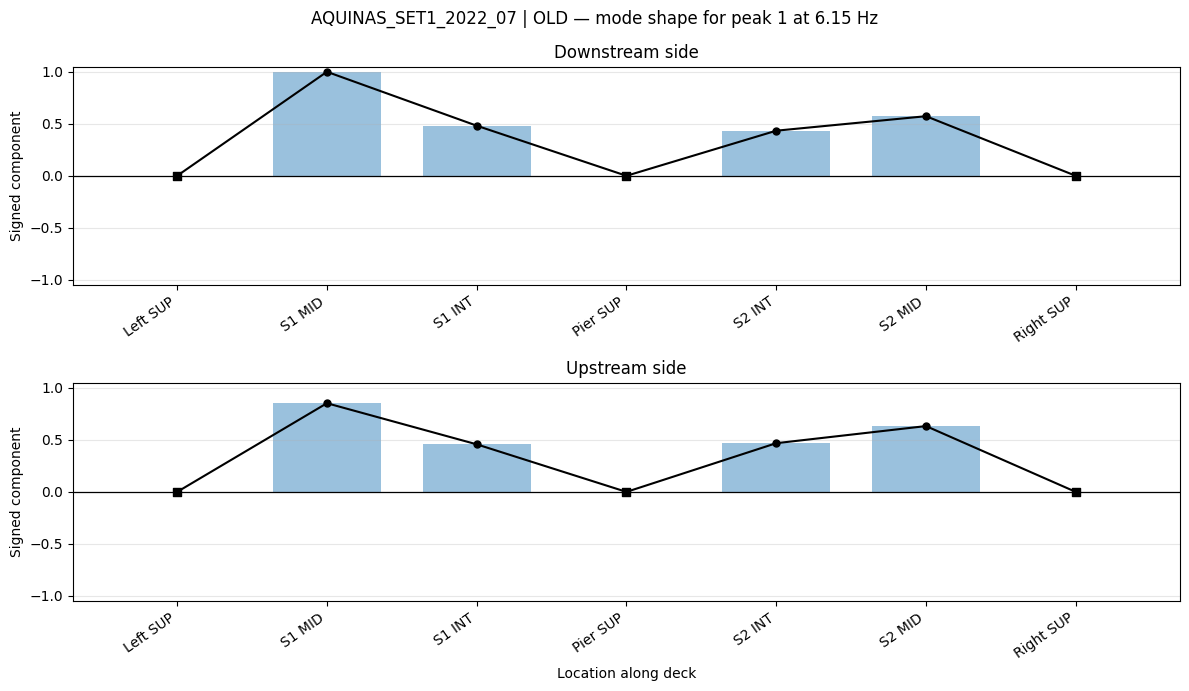

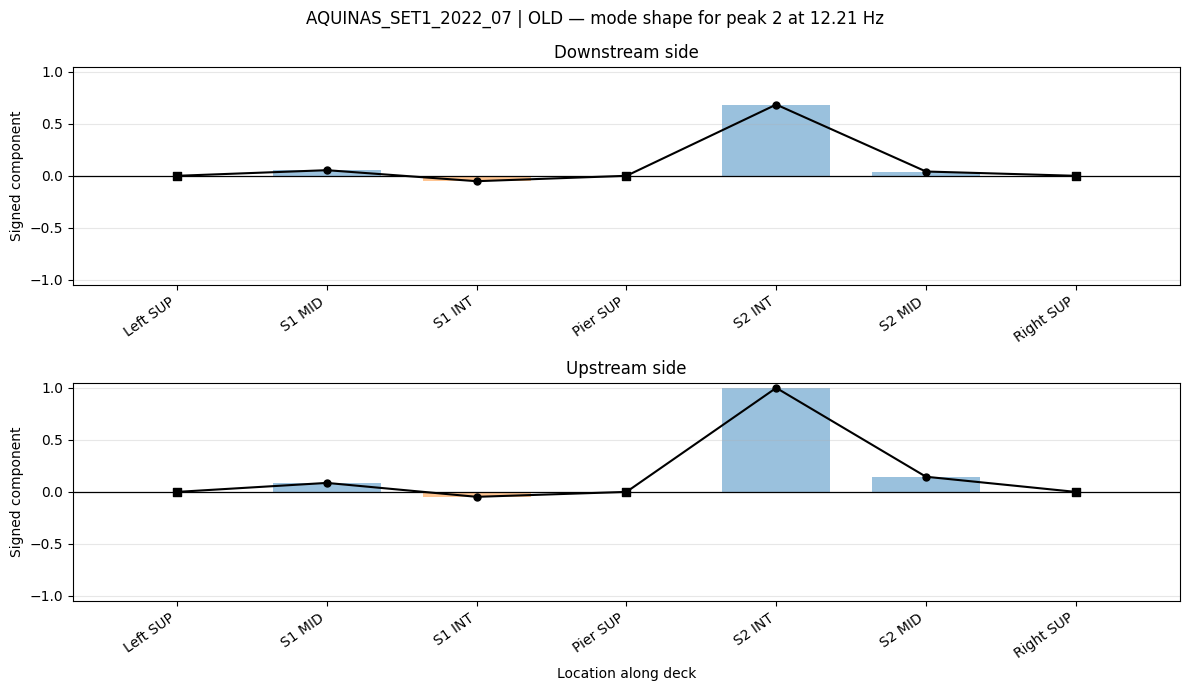

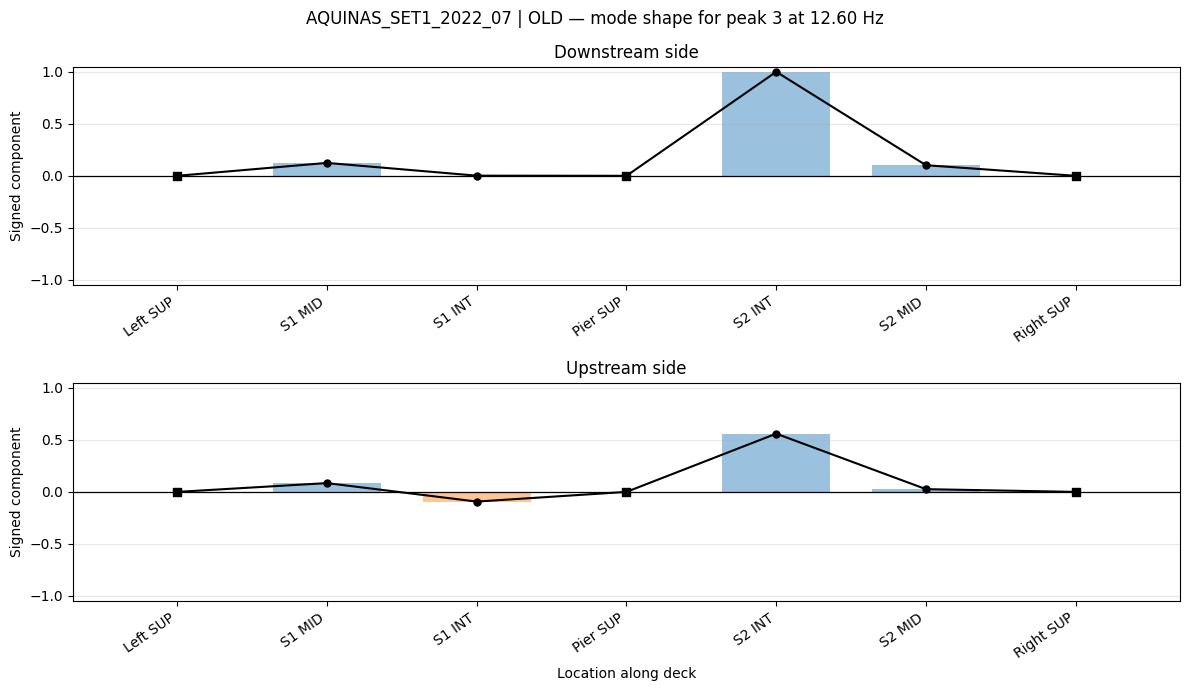

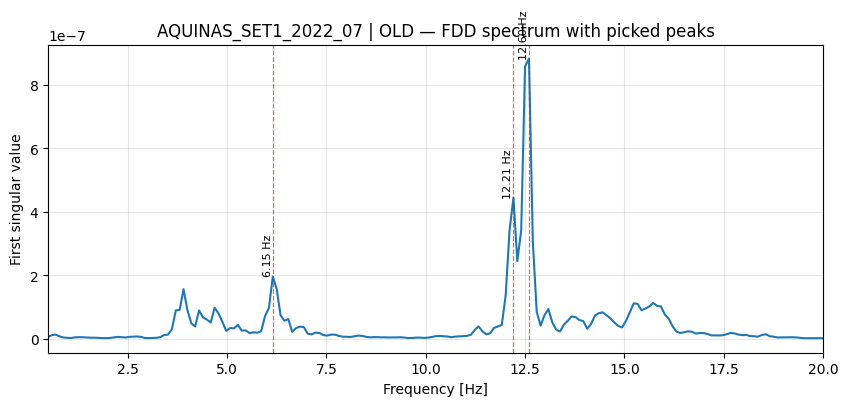

### AQUINAS_SET1_2022_07 | NEW

Frequency [Hz],Singular value
6.15,1.3452e-07
12.60,1.2806e-07
15.82,7.3099e-08


,Peak 1 (6.15 Hz),Peak 2 (12.60 Hz),Peak 3 (15.82 Hz)
Location,,,
S1_DO_INT,+0.582,+0.027,+0.981
S1_DO_MID,+0.974,-0.057,+0.123
S1_UP_INT,+0.483,-0.054,+1.000
S1_UP_MID,+1.000,+0.121,+0.153
S2_DO_INT,+0.333,+1.000,+0.098
S2_DO_MID,+0.547,-0.221,+0.097
S2_UP_INT,+0.486,+0.688,+0.083
S2_UP_MID,+0.568,-0.052,+0.046


,Peak 1 (6.15 Hz),Peak 2 (12.60 Hz),Peak 3 (15.82 Hz)
Location,,,
S1_DO_INT,0.586,0.029,0.989
S1_DO_MID,0.974,0.199,0.124
S1_UP_INT,0.486,0.098,1.000
S1_UP_MID,1.000,0.129,0.156
S2_DO_INT,0.359,1.000,0.102
S2_DO_MID,0.575,0.222,0.130
S2_UP_INT,0.495,0.815,0.161
S2_UP_MID,0.575,0.053,0.119


,Peak 1 (6.15 Hz),Peak 2 (12.60 Hz),Peak 3 (15.82 Hz)
Location,,,
S1_DO_INT,6.6,-19.7,7.4
S1_DO_MID,-0.6,-106.6,-6.1
S1_UP_INT,6.7,123.2,-0.0
S1_UP_MID,-0.0,20.9,11.8
S2_DO_INT,22.0,0.0,15.8
S2_DO_MID,18.0,175.9,42.2
S2_UP_INT,11.1,-32.5,58.9
S2_UP_MID,9.1,-172.5,67.1


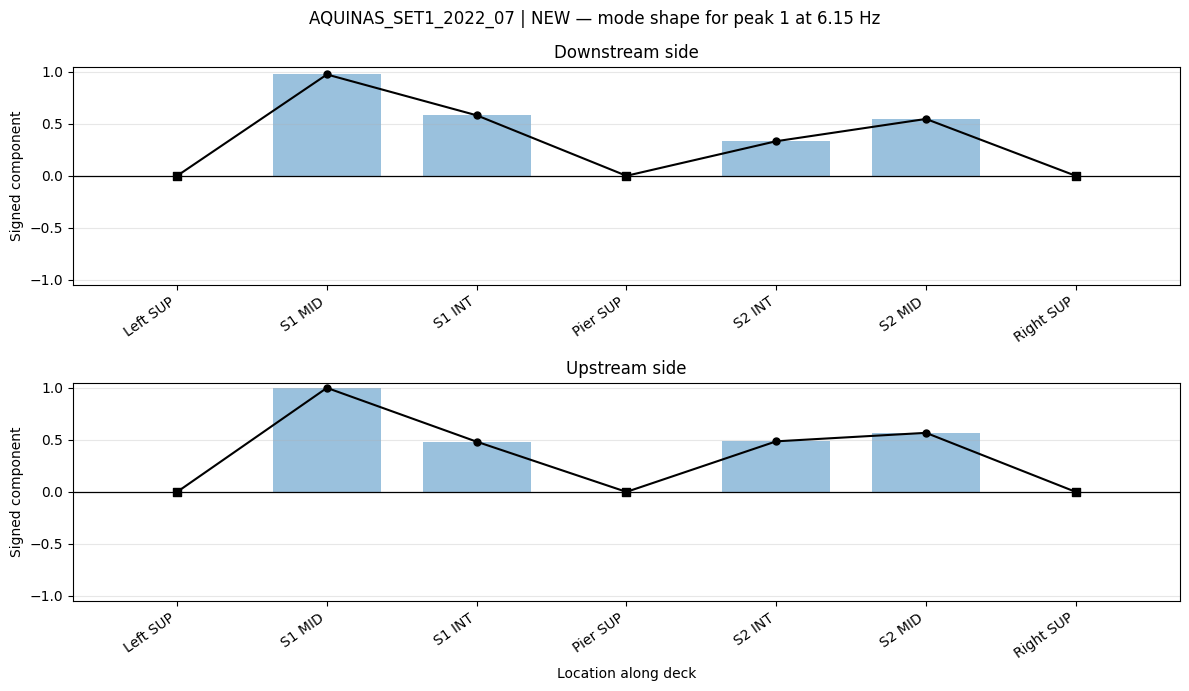

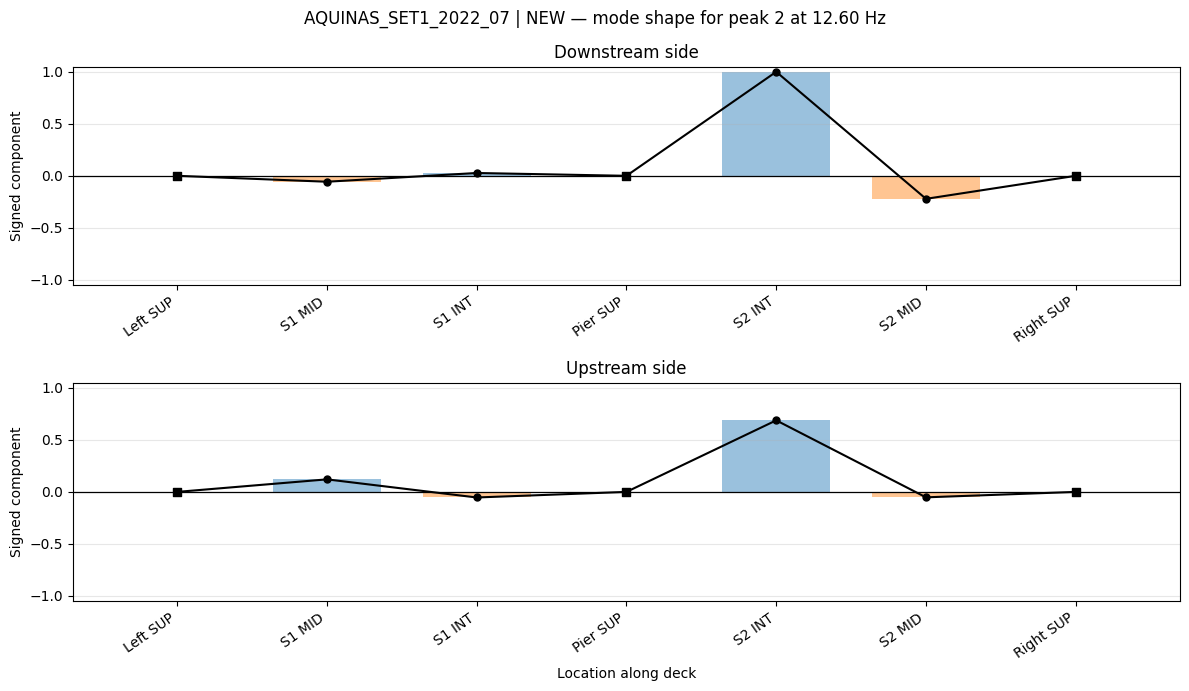

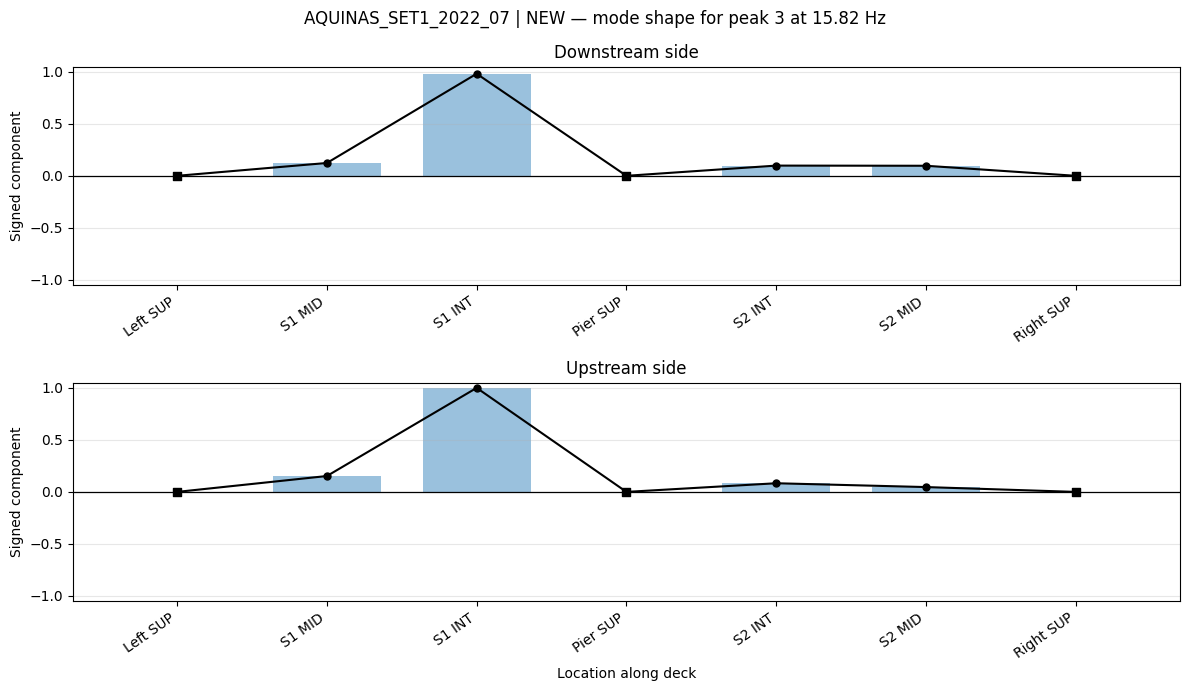

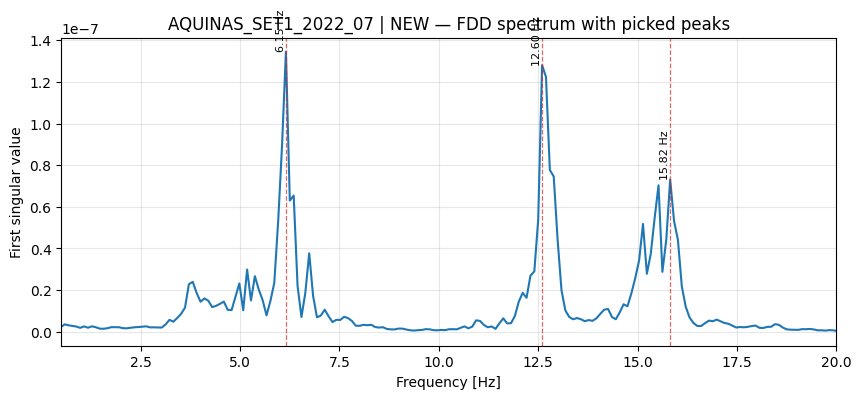

### AQUINAS_SET2_2023_04 | OLD

Frequency [Hz],Singular value
12.60,4.3095e-07
14.84,4.3097e-07
15.53,3.4739e-07


,Peak 1 (12.60 Hz),Peak 2 (14.84 Hz),Peak 3 (15.53 Hz)
Location,,,
S1_DO_INT,+0.163,+0.708,+0.171
S1_DO_MID,+0.245,+0.039,-0.045
S1_UP_INT,-0.022,+1.000,+1.000
S1_UP_MID,-0.074,+0.329,+0.272
S2_DO_INT,+1.000,-0.033,+0.014
S2_DO_MID,+0.403,+0.117,+0.027
S2_UP_INT,-0.172,+0.051,+0.028
S2_UP_MID,+0.003,+0.067,+0.044


,Peak 1 (12.60 Hz),Peak 2 (14.84 Hz),Peak 3 (15.53 Hz)
Location,,,
S1_DO_INT,0.632,0.756,0.548
S1_DO_MID,0.369,0.055,0.049
S1_UP_INT,0.166,1.000,1.000
S1_UP_MID,0.136,0.331,0.273
S2_DO_INT,1.000,0.047,0.046
S2_DO_MID,0.421,0.118,0.056
S2_UP_INT,0.281,0.149,0.087
S2_UP_MID,0.063,0.081,0.054


,Peak 1 (12.60 Hz),Peak 2 (14.84 Hz),Peak 3 (15.53 Hz)
Location,,,
S1_DO_INT,75.1,-20.5,-71.8
S1_DO_MID,-48.4,-45.0,-158.3
S1_UP_INT,97.7,0.0,-0.0
S1_UP_MID,123.3,-6.1,5.3
S2_DO_INT,0.0,-134.6,71.7
S2_DO_MID,-16.8,-7.4,-61.2
S2_UP_INT,127.7,70.0,71.0
S2_UP_MID,86.9,33.9,35.2


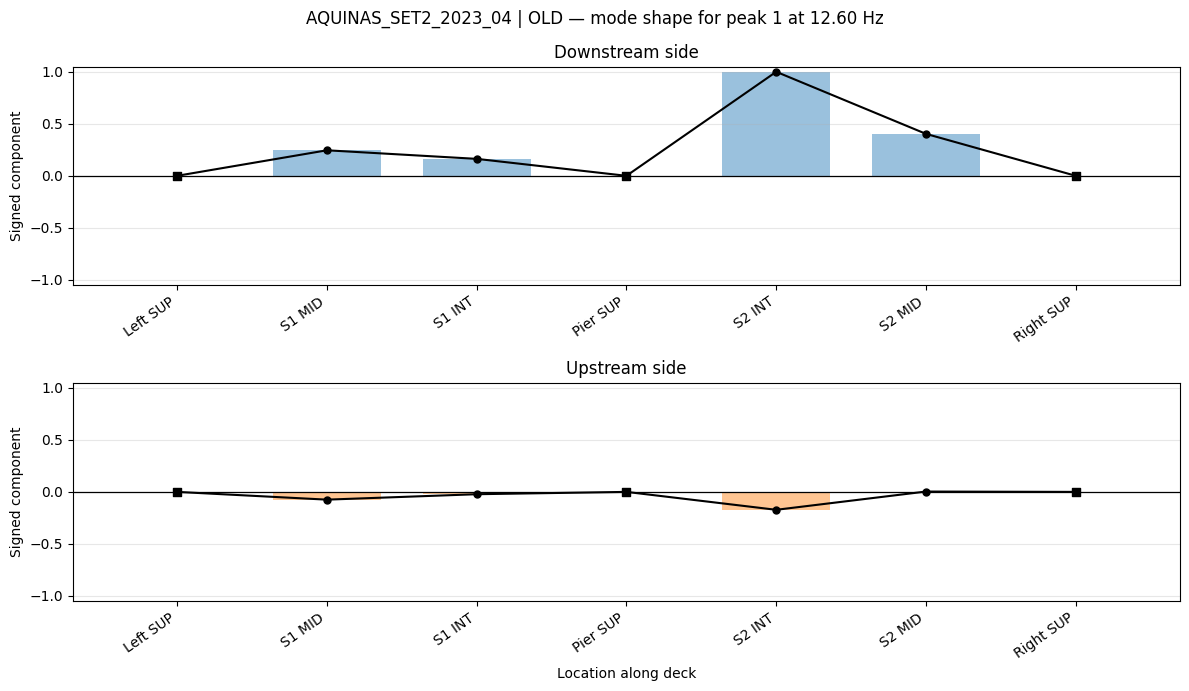

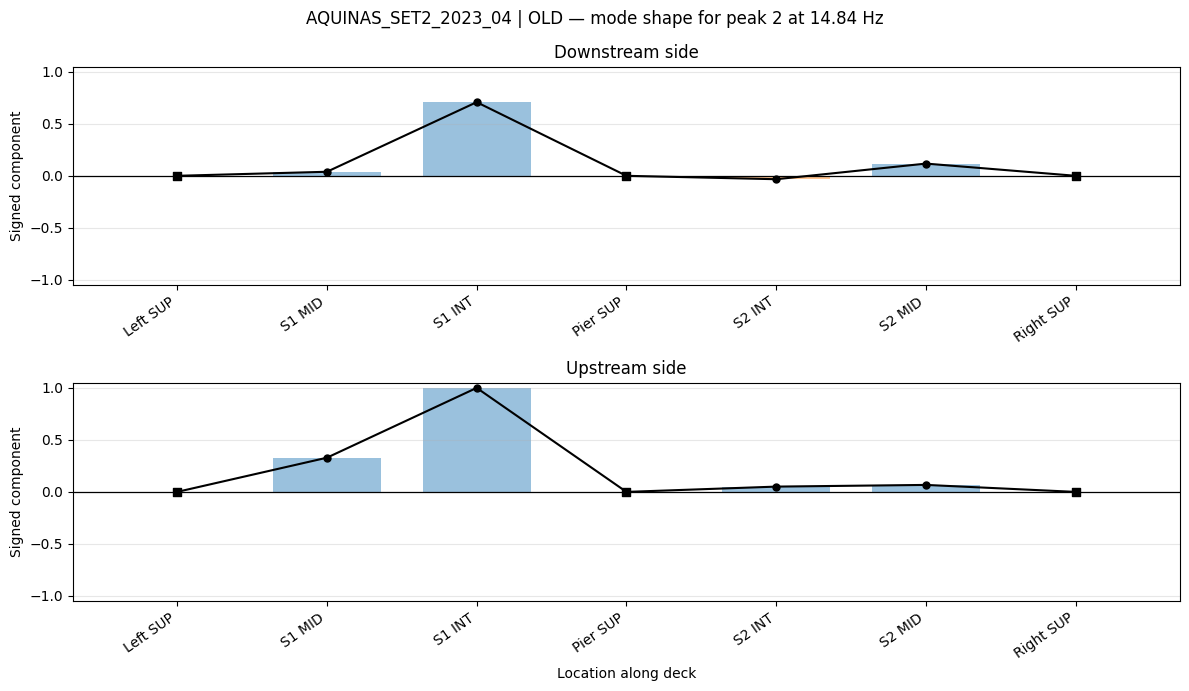

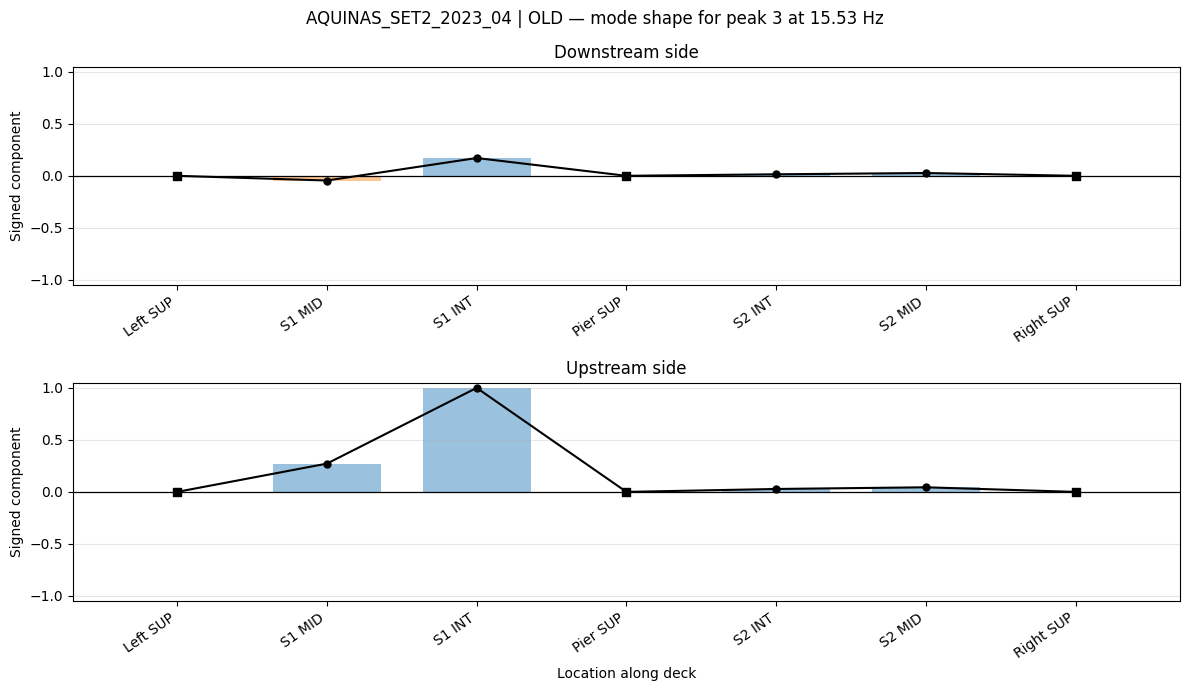

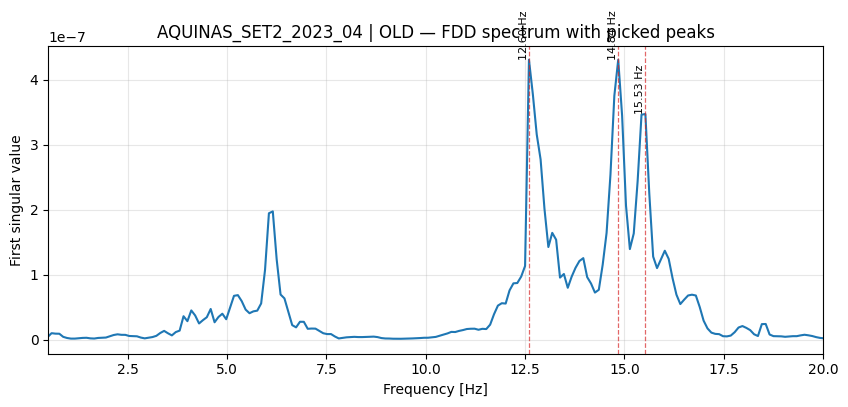

### AQUINAS_SET2_2023_04 | NEW

Frequency [Hz],Singular value
6.25,2.1711e-07
12.60,7.5597e-08
15.53,1.2649e-07


,Peak 1 (6.25 Hz),Peak 2 (12.60 Hz),Peak 3 (15.53 Hz)
Location,,,
S1_DO_INT,+0.473,-0.229,+1.000
S1_DO_MID,+0.946,-0.467,+0.167
S1_UP_INT,+0.528,-0.019,+0.268
S1_UP_MID,+1.000,-0.073,+0.015
S2_DO_INT,+0.455,+1.000,+0.051
S2_DO_MID,+0.590,-0.346,+0.103
S2_UP_INT,+0.473,-0.107,-0.094
S2_UP_MID,+0.620,-0.112,-0.079


,Peak 1 (6.25 Hz),Peak 2 (12.60 Hz),Peak 3 (15.53 Hz)
Location,,,
S1_DO_INT,0.494,0.423,1.000
S1_DO_MID,0.972,0.494,0.172
S1_UP_INT,0.528,0.022,0.886
S1_UP_MID,1.000,0.080,0.199
S2_DO_INT,0.470,1.000,0.052
S2_DO_MID,0.615,0.398,0.104
S2_UP_INT,0.475,0.164,0.138
S2_UP_MID,0.623,0.136,0.086


,Peak 1 (6.25 Hz),Peak 2 (12.60 Hz),Peak 3 (15.53 Hz)
Location,,,
S1_DO_INT,16.8,-122.9,0.0
S1_DO_MID,13.5,160.9,-13.9
S1_UP_INT,2.0,-150.4,72.4
S1_UP_MID,-0.0,156.4,85.6
S2_DO_INT,-14.6,-0.0,-11.3
S2_DO_MID,-16.5,-150.4,-7.6
S2_UP_INT,4.7,-130.7,132.9
S2_UP_MID,5.6,-145.6,156.2


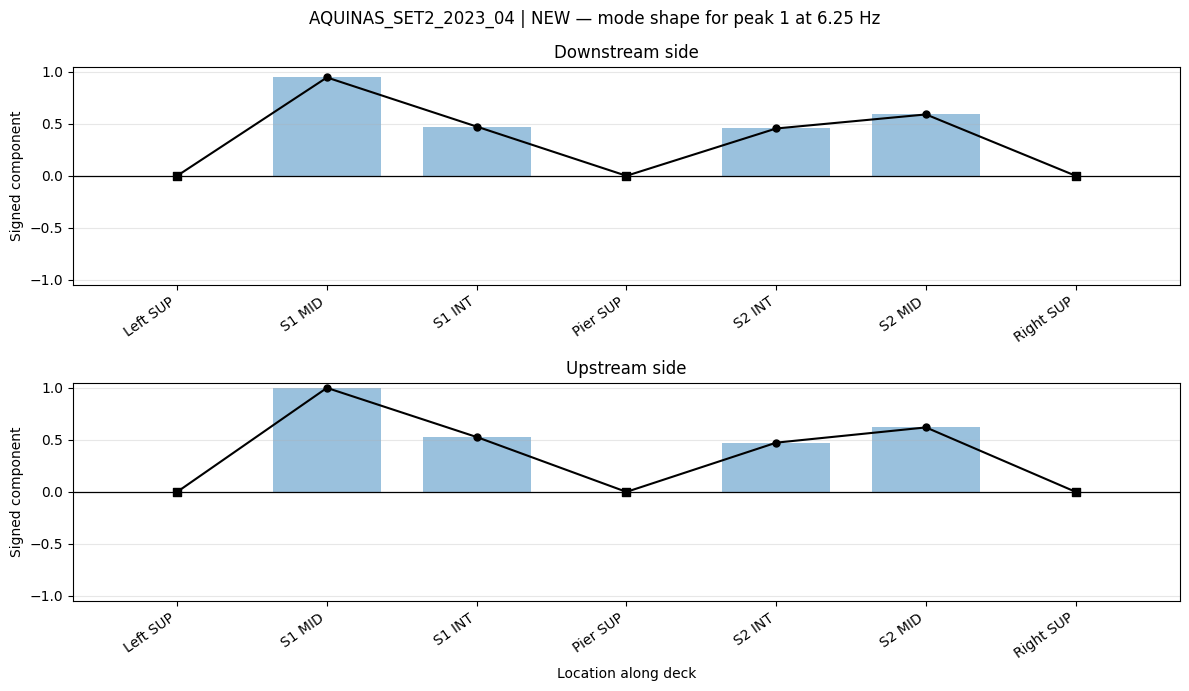

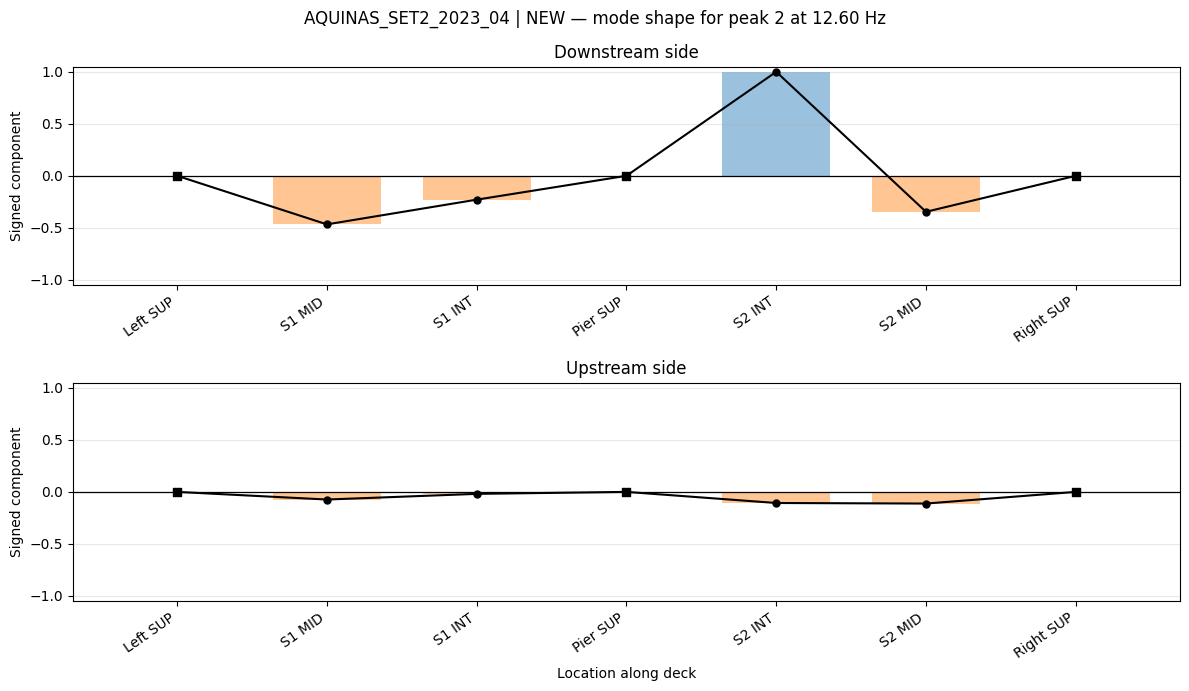

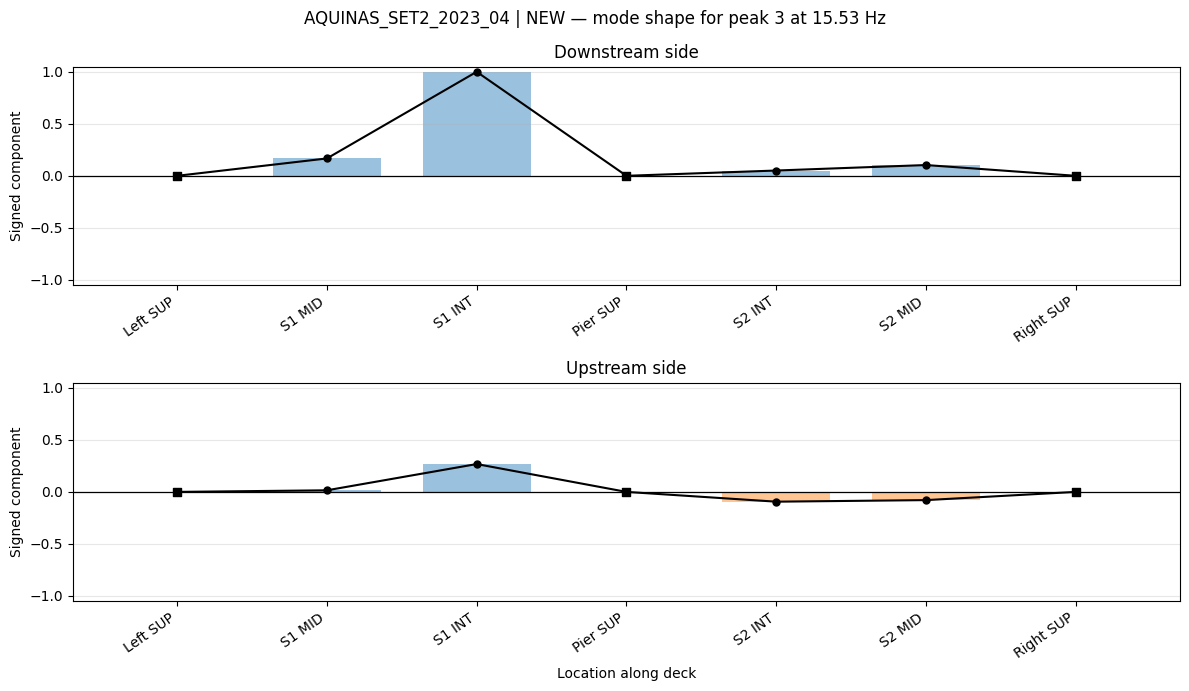

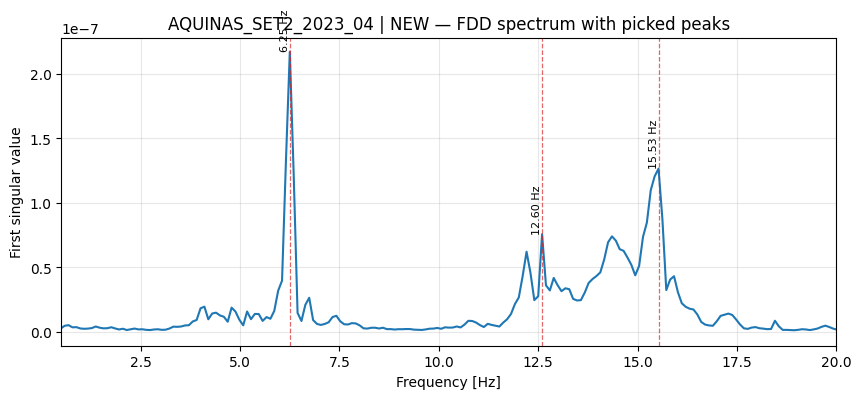

### AQUINAS_SET3_2023_08 | OLD

Frequency [Hz],Singular value
6.05,5.0945e-07
12.70,2.6464e-07
15.04,4.9280e-07


,Peak 1 (6.05 Hz),Peak 2 (12.70 Hz),Peak 3 (15.04 Hz)
Location,,,
S1_DO_INT,+0.428,-0.025,-0.634
S1_DO_MID,+0.644,+0.194,+0.127
S1_UP_INT,+0.495,-0.028,+1.000
S1_UP_MID,+1.000,+0.025,+0.323
S2_DO_INT,+0.253,+1.000,+0.014
S2_DO_MID,+0.505,-0.363,-0.114
S2_UP_INT,+0.486,+0.640,+0.035
S2_UP_MID,+0.693,+0.133,+0.083


,Peak 1 (6.05 Hz),Peak 2 (12.70 Hz),Peak 3 (15.04 Hz)
Location,,,
S1_DO_INT,0.519,0.812,0.829
S1_DO_MID,0.865,0.280,0.150
S1_UP_INT,0.496,0.074,1.000
S1_UP_MID,1.000,0.132,0.324
S2_DO_INT,0.453,1.000,0.106
S2_DO_MID,0.608,0.401,0.116
S2_UP_INT,0.499,0.668,0.049
S2_UP_MID,0.703,0.144,0.093


,Peak 1 (6.05 Hz),Peak 2 (12.70 Hz),Peak 3 (15.04 Hz)
Location,,,
S1_DO_INT,34.4,-91.8,139.9
S1_DO_MID,41.9,-46.1,32.0
S1_UP_INT,3.1,112.3,-0.0
S1_UP_MID,0.0,79.2,-4.8
S2_DO_INT,56.0,0.0,82.3
S2_DO_MID,33.9,-154.9,171.8
S2_UP_INT,13.2,-16.8,44.0
S2_UP_MID,9.7,-22.7,26.8


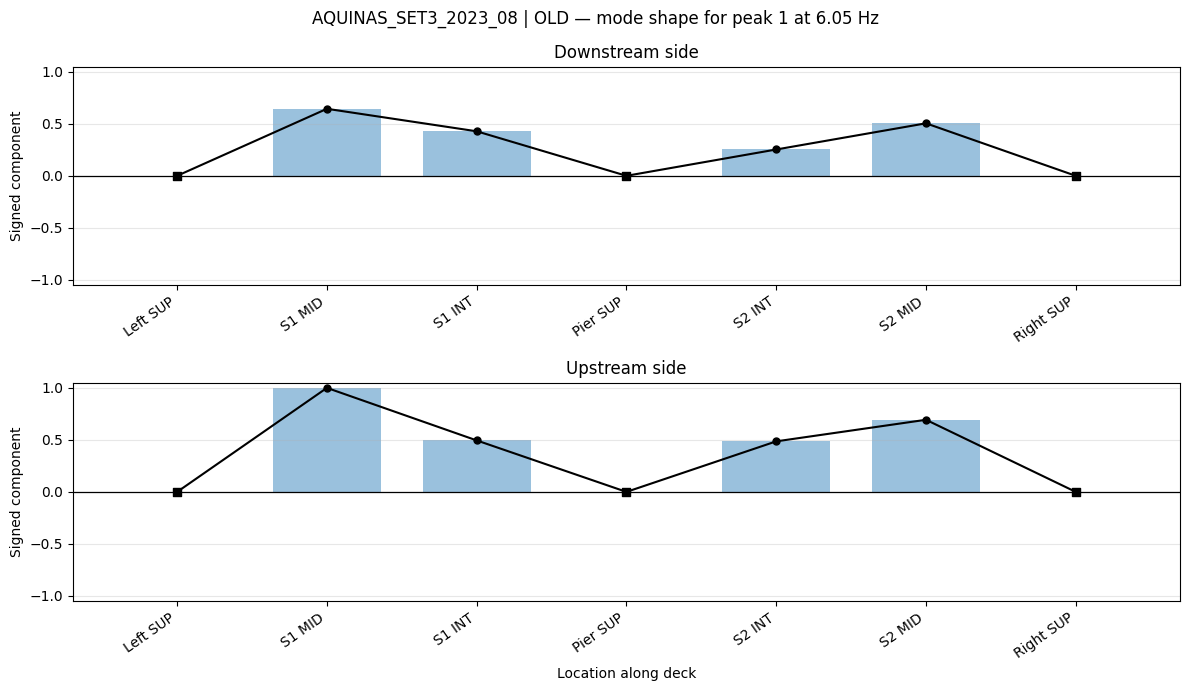

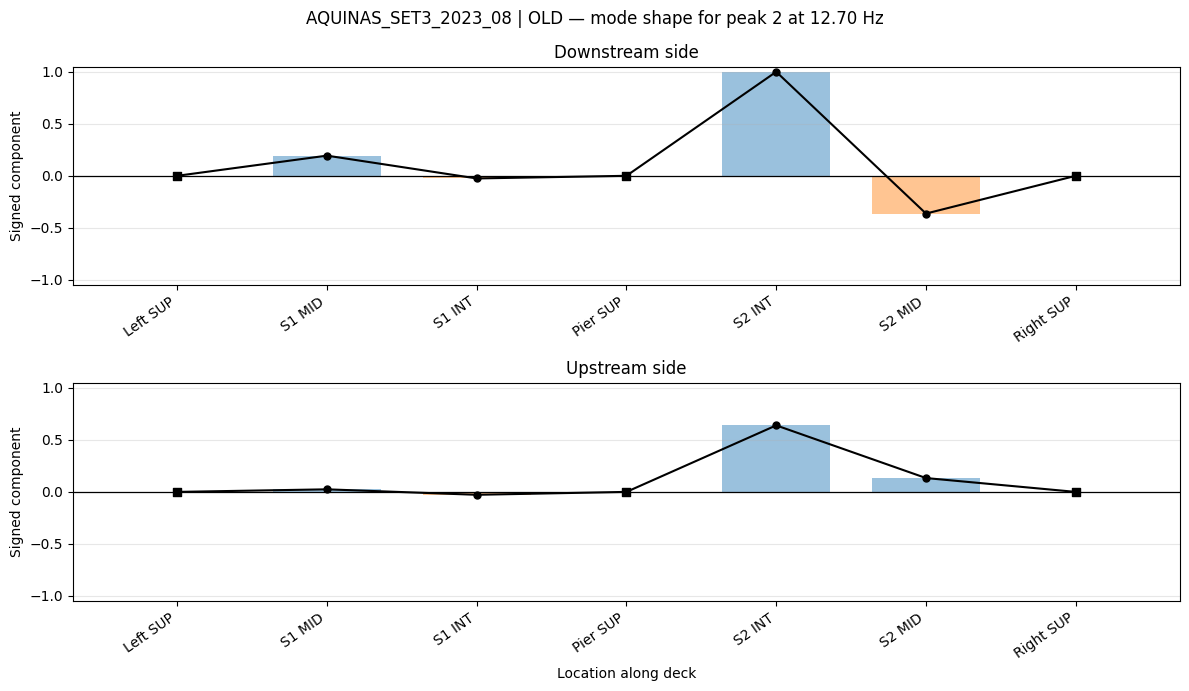

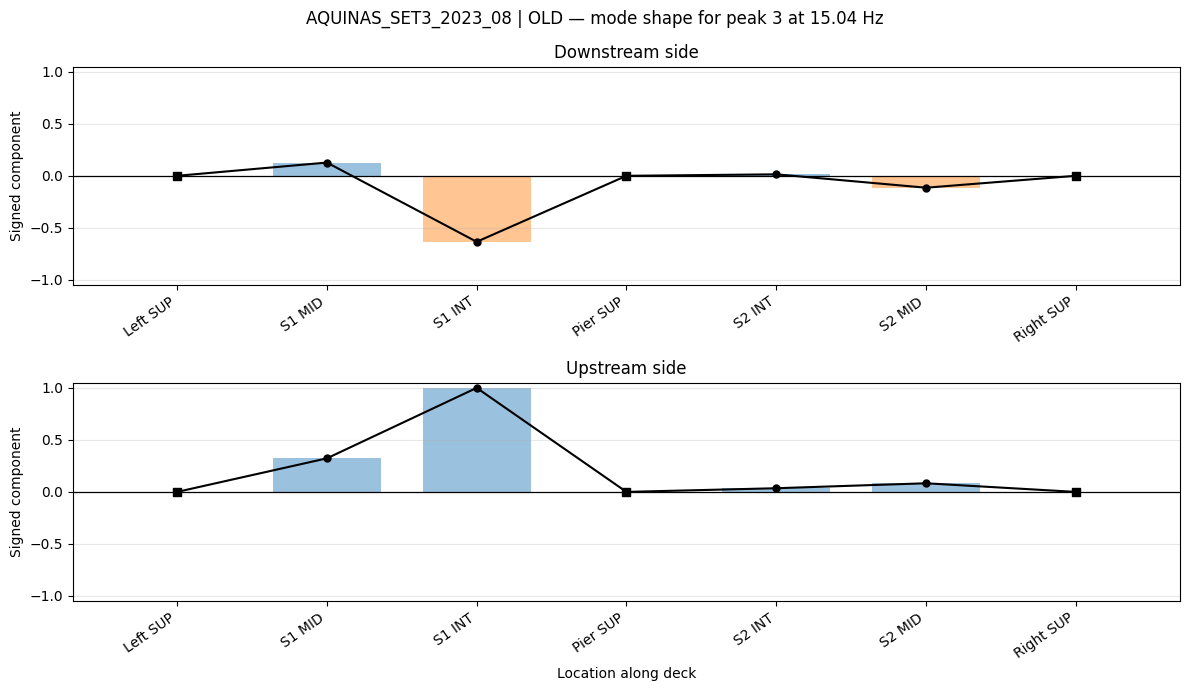

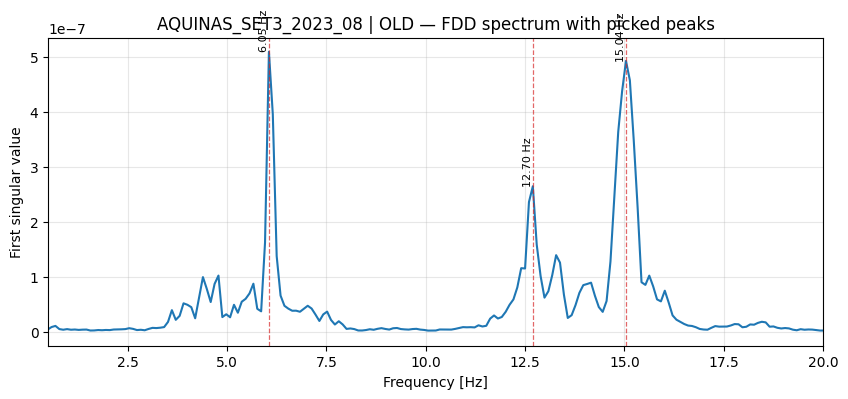

### AQUINAS_SET3_2023_08 | NEW

Frequency [Hz],Singular value
6.15,1.5064e-07
12.21,6.3241e-08
12.60,1.5298e-07


,Peak 1 (6.15 Hz),Peak 2 (12.21 Hz),Peak 3 (12.60 Hz)
Location,,,
S1_DO_INT,+0.527,-0.050,-0.196
S1_DO_MID,+0.951,+0.132,-0.007
S1_UP_INT,+0.582,-0.025,-0.031
S1_UP_MID,+1.000,+0.155,+0.004
S2_DO_INT,+0.497,+0.561,+1.000
S2_DO_MID,+0.670,-0.082,-0.394
S2_UP_INT,+0.448,+1.000,-0.156
S2_UP_MID,+0.702,-0.009,-0.044


,Peak 1 (6.15 Hz),Peak 2 (12.21 Hz),Peak 3 (12.60 Hz)
Location,,,
S1_DO_INT,0.539,0.131,0.202
S1_DO_MID,0.961,0.159,0.221
S1_UP_INT,0.582,0.086,0.036
S1_UP_MID,1.000,0.163,0.013
S2_DO_INT,0.497,0.936,1.000
S2_DO_MID,0.679,0.157,0.435
S2_UP_INT,0.448,1.000,0.207
S2_UP_MID,0.702,0.140,0.061


,Peak 1 (6.15 Hz),Peak 2 (12.21 Hz),Peak 3 (12.60 Hz)
Location,,,
S1_DO_INT,12.1,112.4,-165.9
S1_DO_MID,8.1,33.8,91.7
S1_UP_INT,-0.6,107.0,-150.9
S1_UP_MID,-0.0,18.9,72.6
S2_DO_INT,-1.7,-53.2,-0.0
S2_DO_MID,-9.2,121.2,-154.7
S2_UP_INT,3.3,0.0,138.7
S2_UP_MID,0.3,93.7,137.0


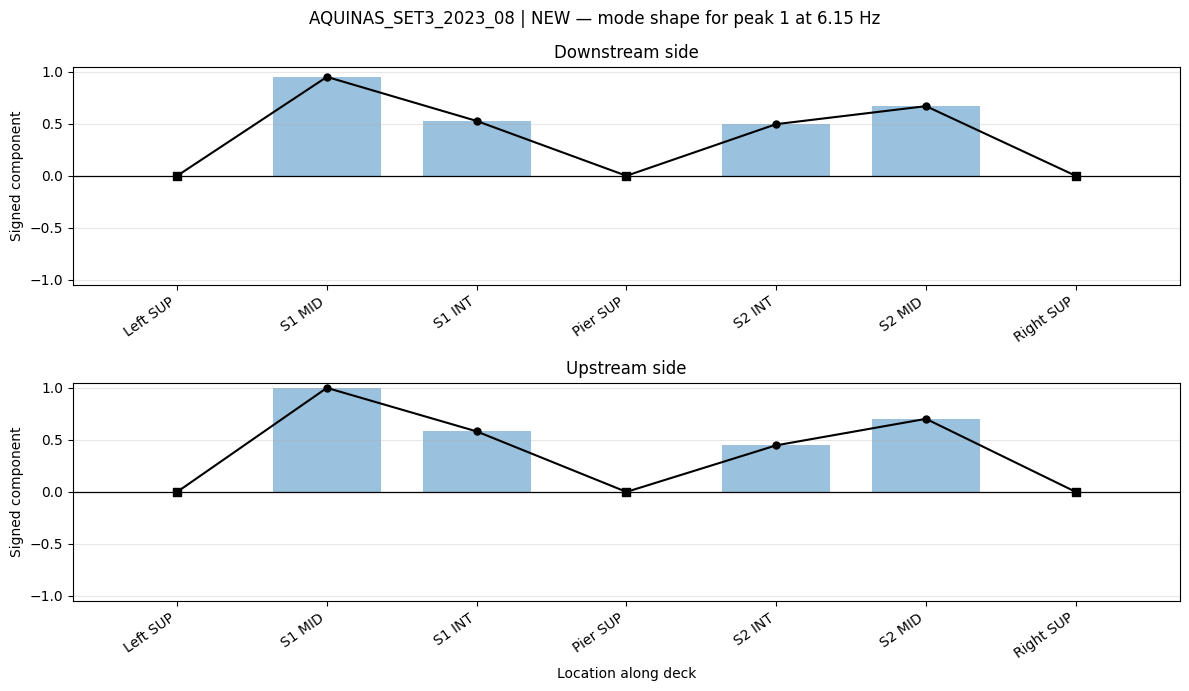

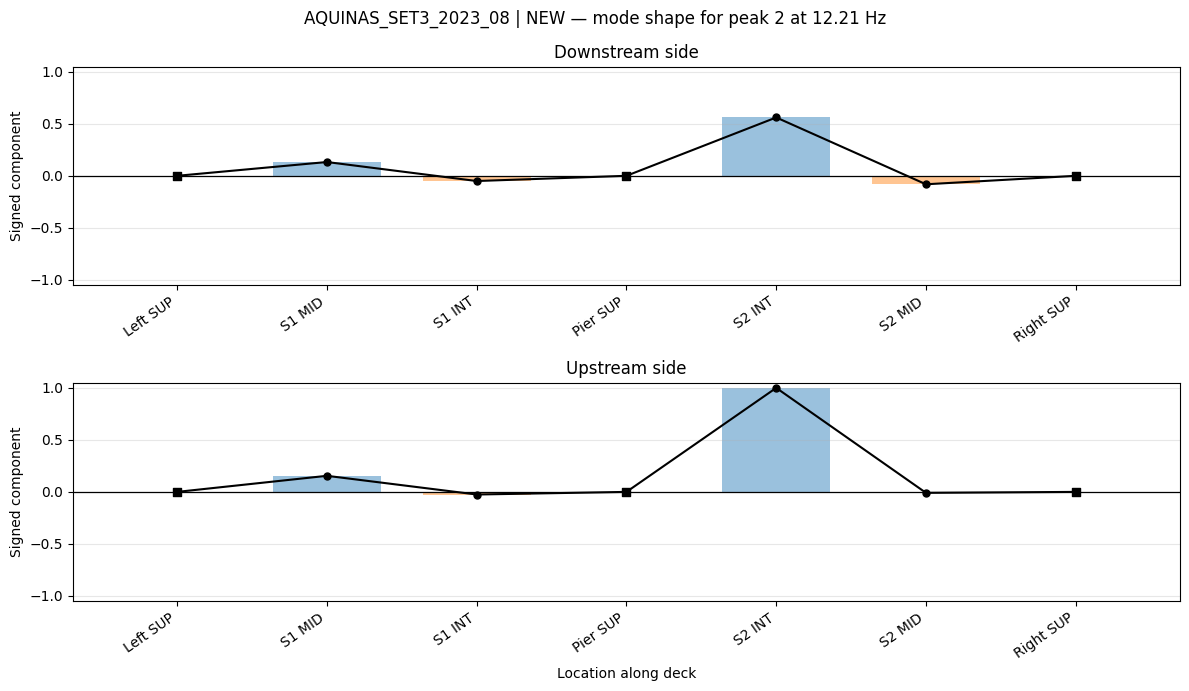

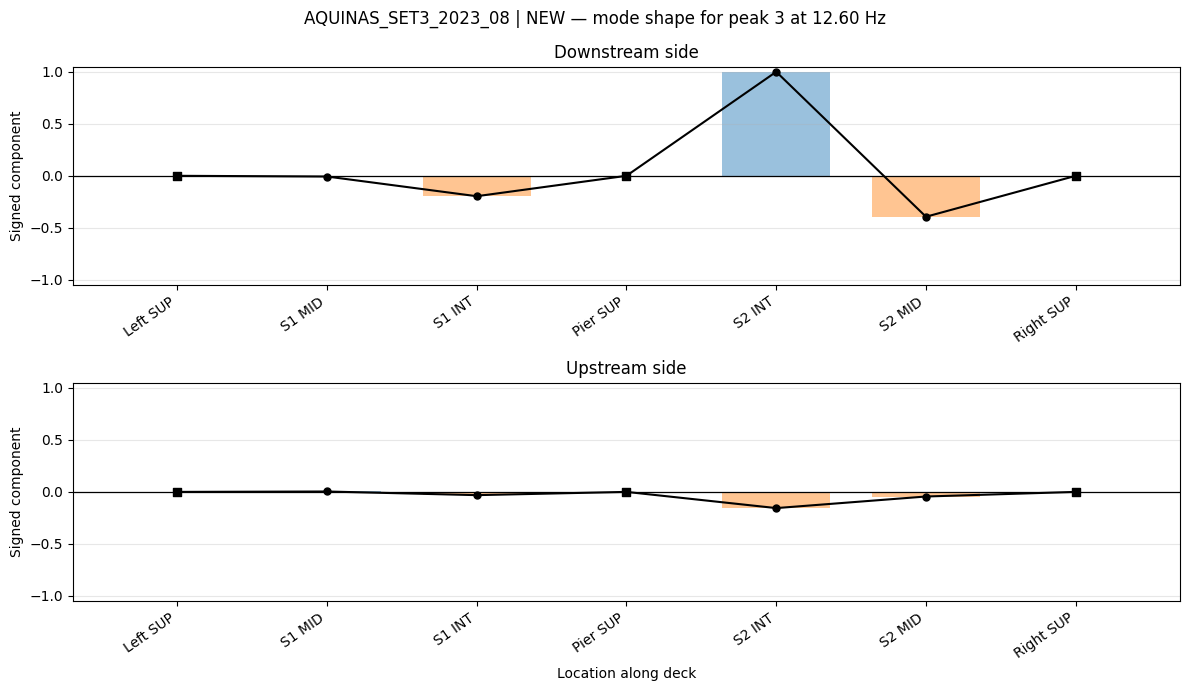

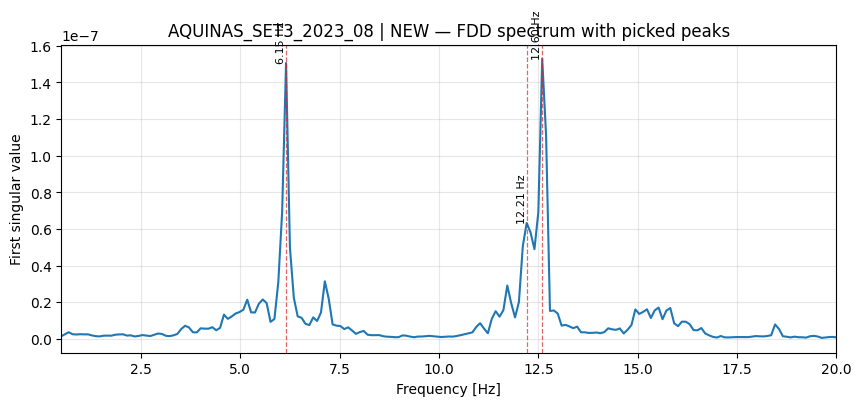

### AQUINAS_SET4_2024_01 | OLD

Frequency [Hz],Singular value
6.15,3.9046e-07
15.23,4.3450e-07
15.82,1.2051e-06


,Peak 1 (6.15 Hz),Peak 2 (15.23 Hz),Peak 3 (15.82 Hz)
Location,,,
S1_DO_INT,+0.494,-0.515,-0.759
S1_DO_MID,+1.000,+0.242,+0.178
S1_UP_INT,+0.455,+1.000,+1.000
S1_UP_MID,+0.870,+0.477,+0.174
S2_DO_INT,+0.465,+0.027,+0.108
S2_DO_MID,+0.591,-0.104,-0.073
S2_UP_INT,+0.375,+0.005,+0.132
S2_UP_MID,+0.548,-0.001,+0.083


,Peak 1 (6.15 Hz),Peak 2 (15.23 Hz),Peak 3 (15.82 Hz)
Location,,,
S1_DO_INT,0.511,0.728,0.963
S1_DO_MID,1.000,0.242,0.197
S1_UP_INT,0.463,1.000,1.000
S1_UP_MID,0.891,0.485,0.174
S2_DO_INT,0.471,0.137,0.134
S2_DO_MID,0.598,0.142,0.089
S2_UP_INT,0.448,0.067,0.141
S2_UP_MID,0.608,0.031,0.089


,Peak 1 (6.15 Hz),Peak 2 (15.23 Hz),Peak 3 (15.82 Hz)
Location,,,
S1_DO_INT,14.8,135.0,142.0
S1_DO_MID,0.0,-4.0,25.6
S1_UP_INT,10.9,-0.0,-0.0
S1_UP_MID,12.5,-10.3,-1.1
S2_DO_INT,9.5,78.7,35.9
S2_DO_MID,9.0,137.3,145.7
S2_UP_INT,33.2,85.4,21.0
S2_UP_MID,25.6,91.0,20.5


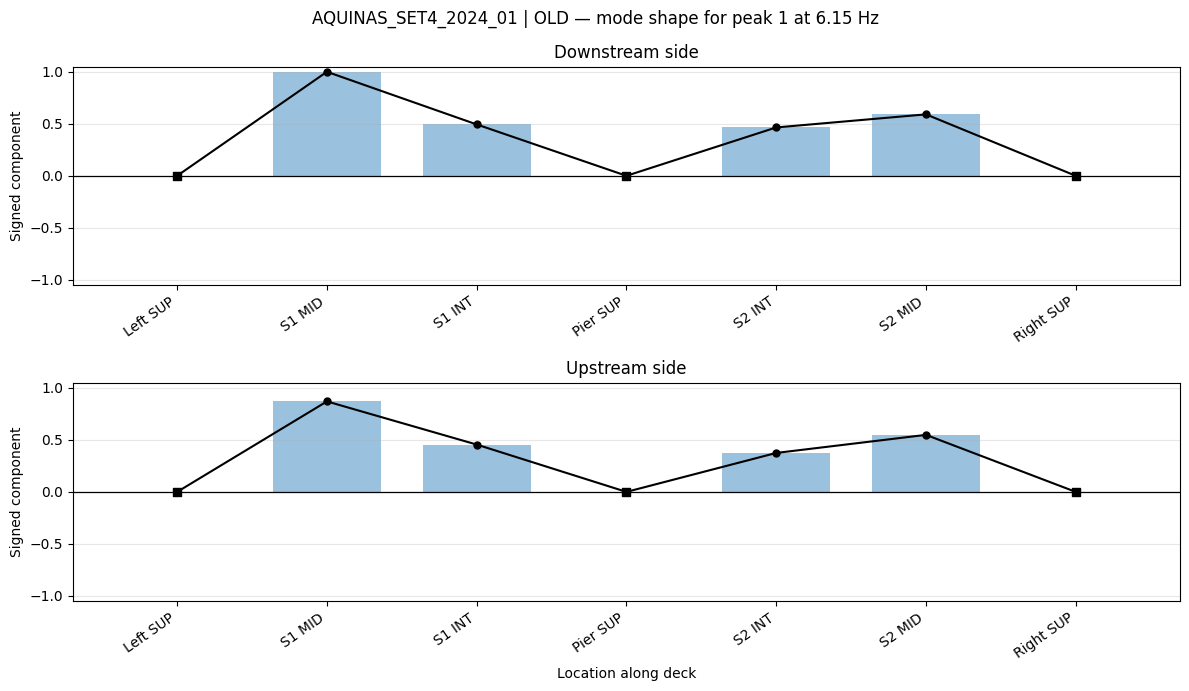

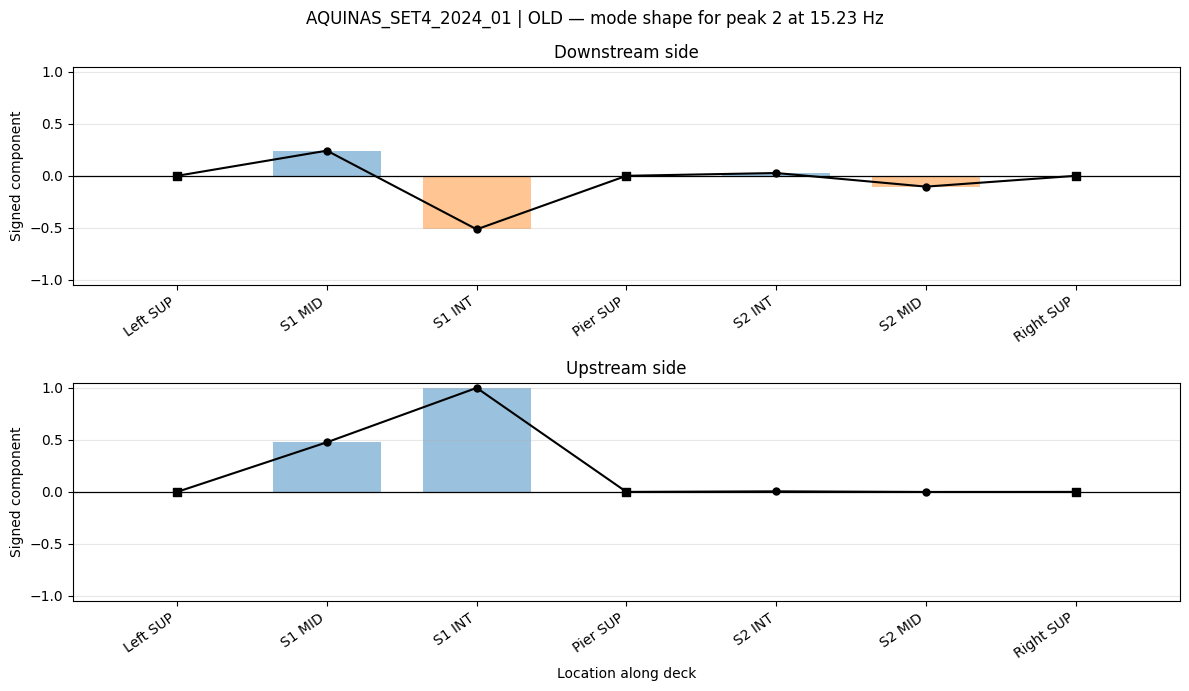

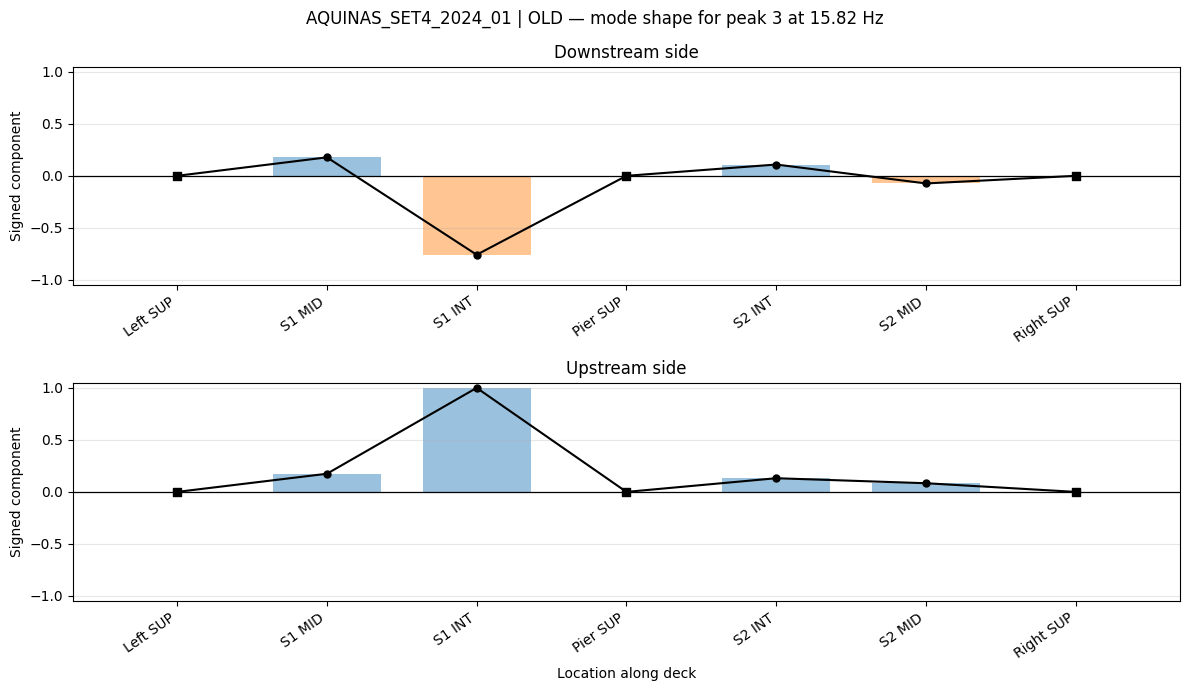

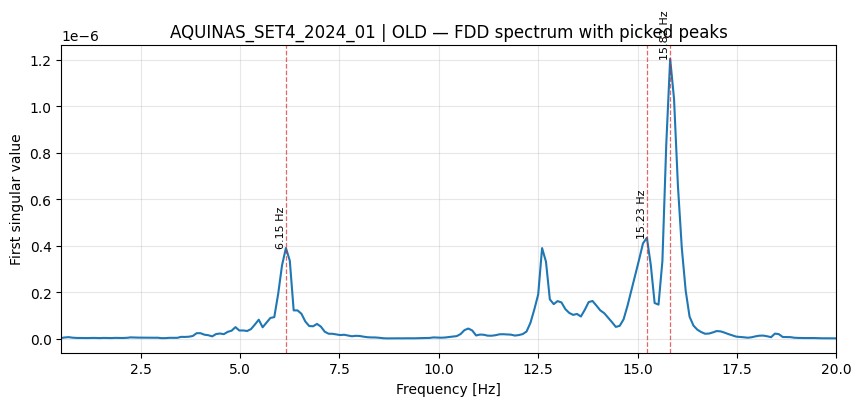

### AQUINAS_SET4_2024_01 | NEW

Frequency [Hz],Singular value
6.25,2.3299e-07
12.60,1.3100e-07
15.33,5.4833e-08


,Peak 1 (6.25 Hz),Peak 2 (12.60 Hz),Peak 3 (15.33 Hz)
Location,,,
S1_DO_INT,+0.636,+0.047,+0.905
S1_DO_MID,+0.952,+0.182,+0.087
S1_UP_INT,+0.593,-0.015,+1.000
S1_UP_MID,+1.000,+0.046,+0.141
S2_DO_INT,+0.471,+1.000,+0.063
S2_DO_MID,+0.626,-0.272,-0.010
S2_UP_INT,+0.506,+0.055,-0.007
S2_UP_MID,+0.710,-0.107,+0.036


,Peak 1 (6.25 Hz),Peak 2 (12.60 Hz),Peak 3 (15.33 Hz)
Location,,,
S1_DO_INT,0.642,0.122,0.970
S1_DO_MID,0.976,0.206,0.128
S1_UP_INT,0.593,0.016,1.000
S1_UP_MID,1.000,0.047,0.145
S2_DO_INT,0.530,1.000,0.075
S2_DO_MID,0.729,0.318,0.087
S2_UP_INT,0.507,0.056,0.200
S2_UP_MID,0.715,0.117,0.089


,Peak 1 (6.25 Hz),Peak 2 (12.60 Hz),Peak 3 (15.33 Hz)
Location,,,
S1_DO_INT,-7.7,67.6,-21.1
S1_DO_MID,-12.6,-27.7,-47.1
S1_UP_INT,2.0,159.3,-0.0
S1_UP_MID,-0.0,-12.3,-12.5
S2_DO_INT,-27.2,-0.0,33.3
S2_DO_MID,-30.8,-148.8,-96.8
S2_UP_INT,-3.2,4.5,92.0
S2_UP_MID,-6.7,155.8,66.2


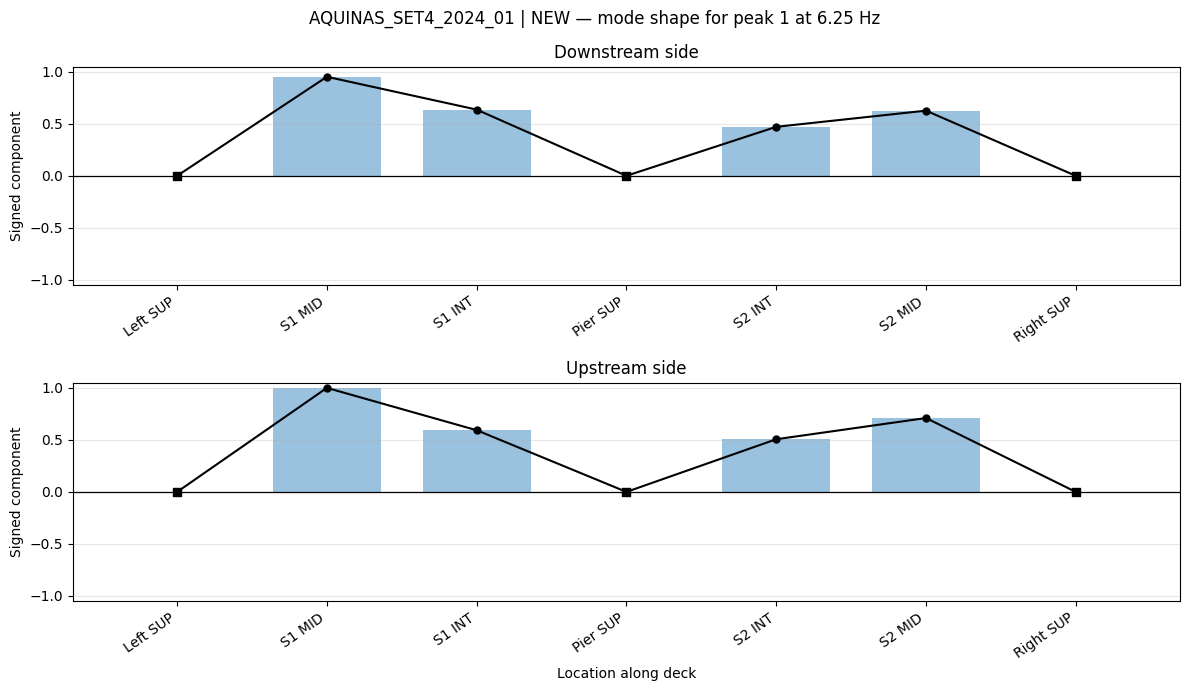

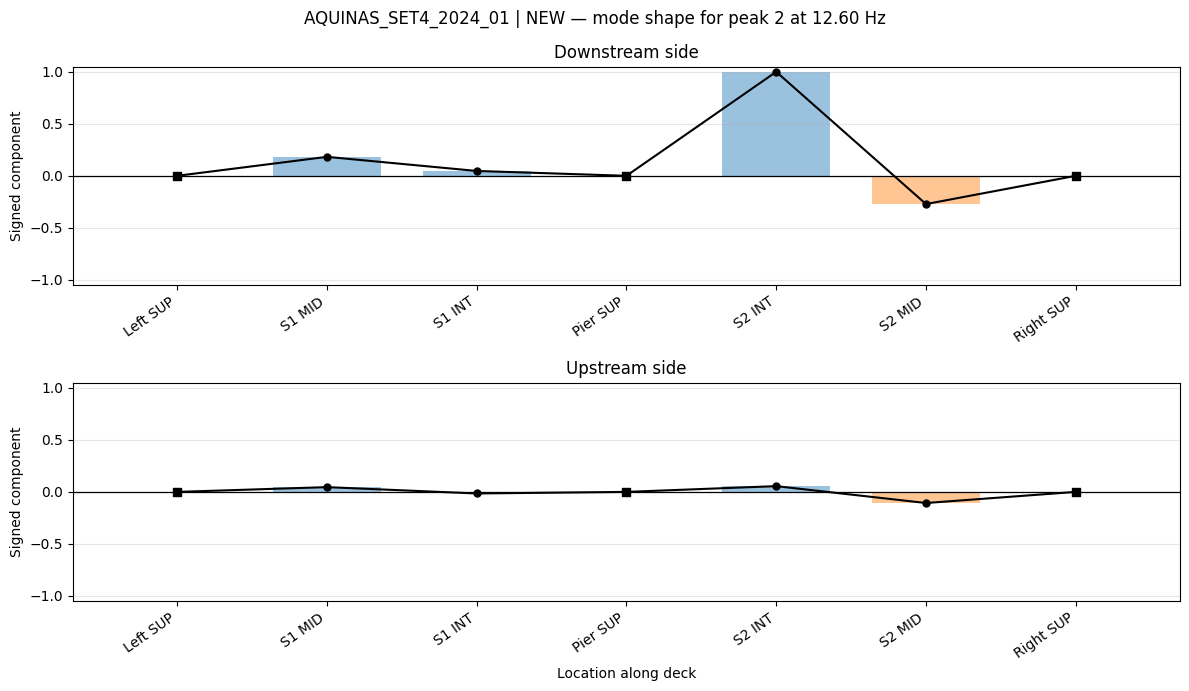

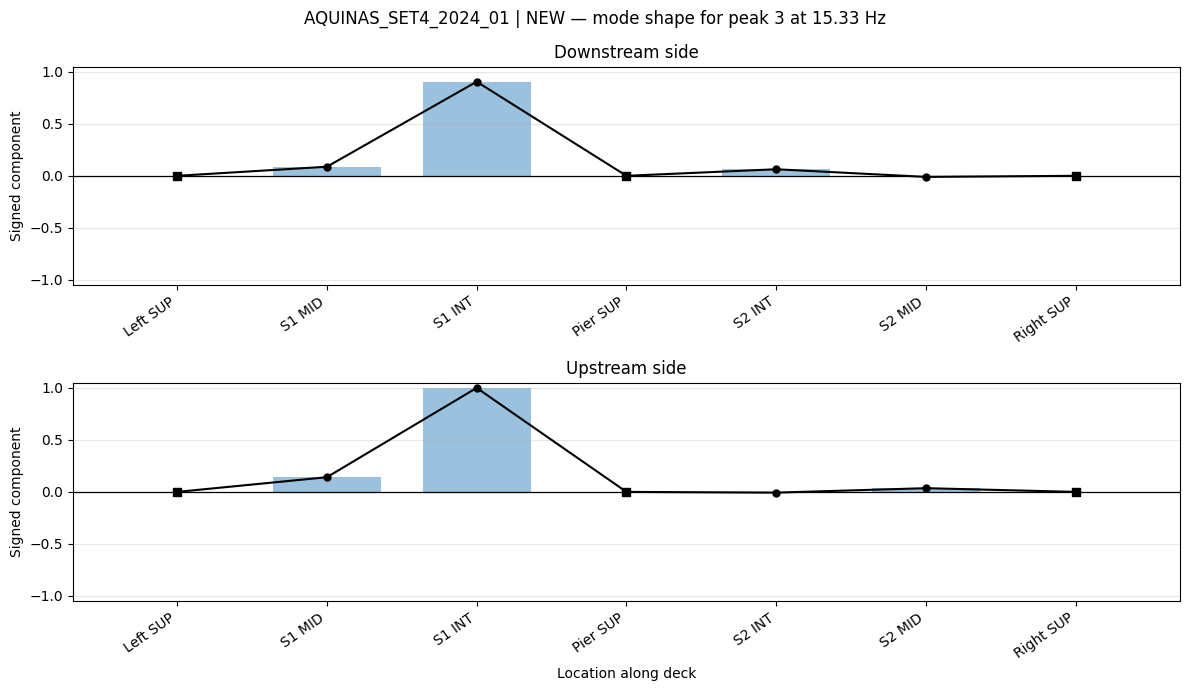

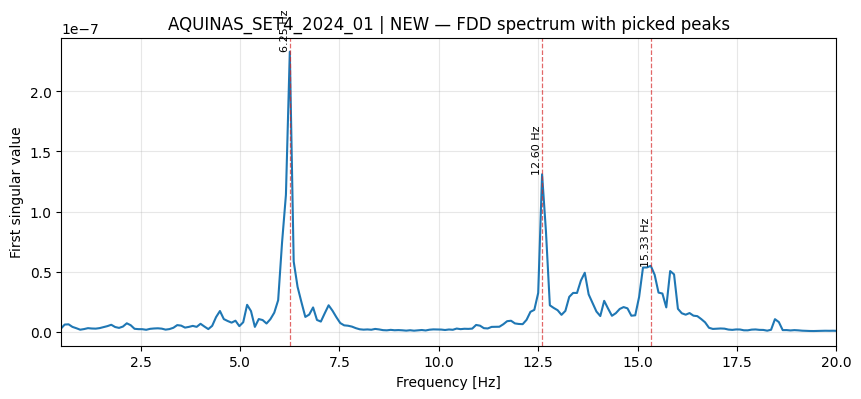

### AQUINAS_SET5_2024_06 | OLD

Frequency [Hz],Singular value
12.60,6.3173e-07
14.45,2.3595e-07
15.72,7.4110e-07


,Peak 1 (12.60 Hz),Peak 2 (14.45 Hz),Peak 3 (15.72 Hz)
Location,,,
S1_DO_INT,+0.545,+0.655,+0.916
S1_DO_MID,+0.202,+0.243,-0.013
S1_UP_INT,-0.028,+1.000,+1.000
S1_UP_MID,+0.003,+0.324,+0.282
S2_DO_INT,+1.000,+0.355,+0.055
S2_DO_MID,+0.005,+0.129,+0.097
S2_UP_INT,+0.029,+0.190,+0.034
S2_UP_MID,-0.030,+0.141,+0.055


,Peak 1 (12.60 Hz),Peak 2 (14.45 Hz),Peak 3 (15.72 Hz)
Location,,,
S1_DO_INT,0.545,0.876,0.916
S1_DO_MID,0.226,0.265,0.146
S1_UP_INT,0.037,1.000,1.000
S1_UP_MID,0.020,0.332,0.282
S2_DO_INT,1.000,0.355,0.085
S2_DO_MID,0.319,0.155,0.100
S2_UP_INT,0.468,0.322,0.060
S2_UP_MID,0.068,0.145,0.087


,Peak 1 (12.60 Hz),Peak 2 (14.45 Hz),Peak 3 (15.72 Hz)
Location,,,
S1_DO_INT,-1.3,-41.5,0.9
S1_DO_MID,-26.8,-23.1,-95.2
S1_UP_INT,-138.8,-0.0,-0.0
S1_UP_MID,81.9,12.4,0.6
S2_DO_INT,0.0,-0.8,-50.1
S2_DO_MID,-89.2,-34.0,12.7
S2_UP_INT,86.4,53.9,55.2
S2_UP_MID,115.6,14.4,50.6


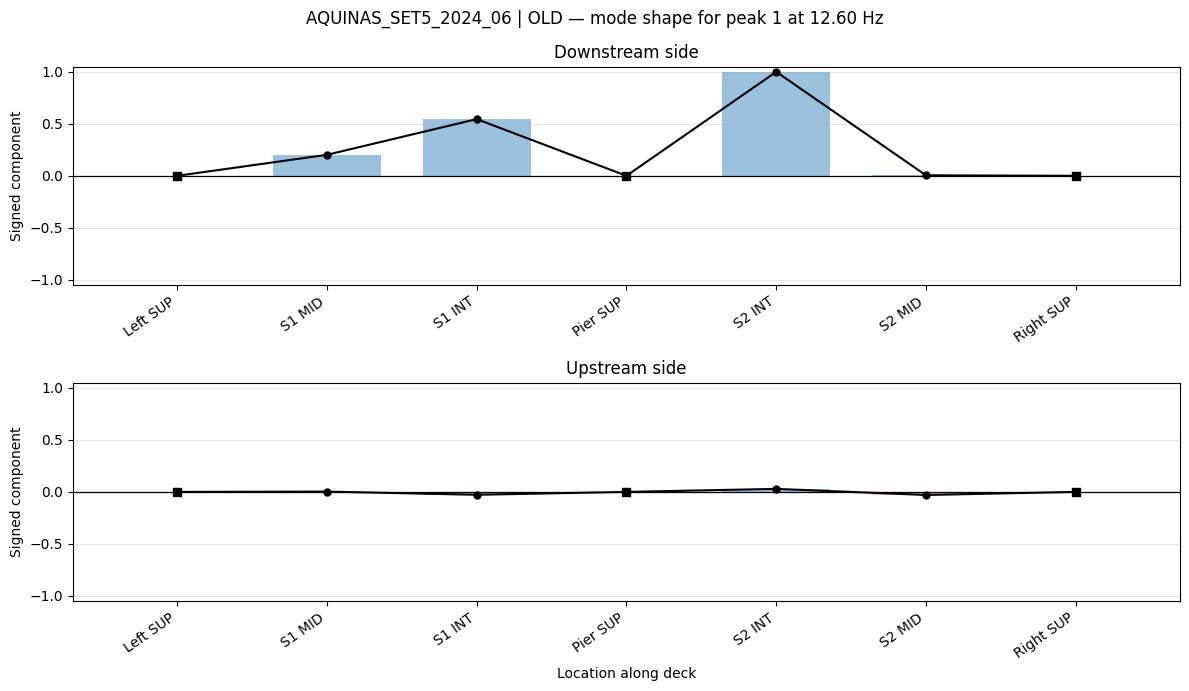

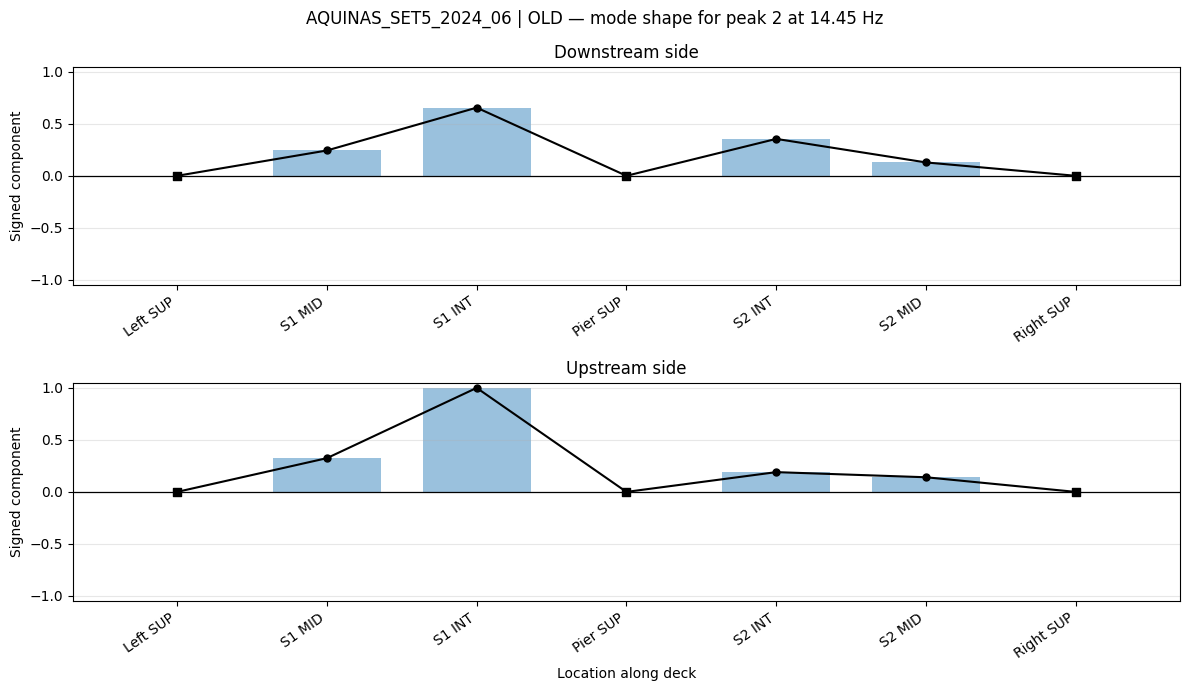

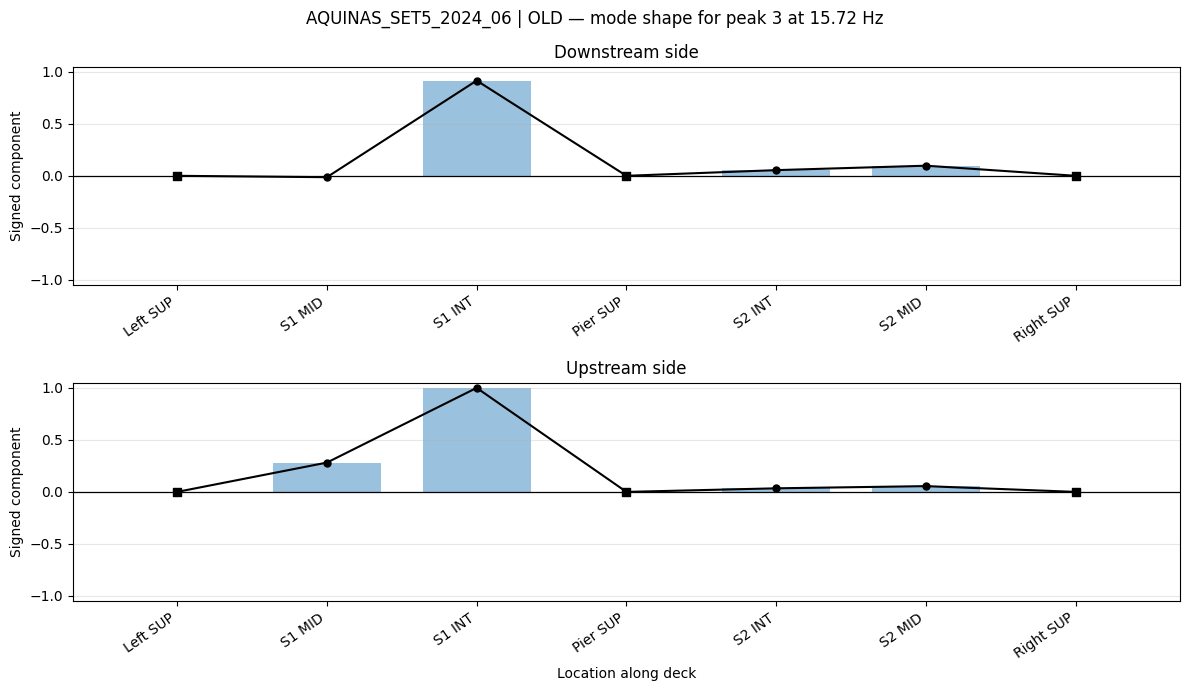

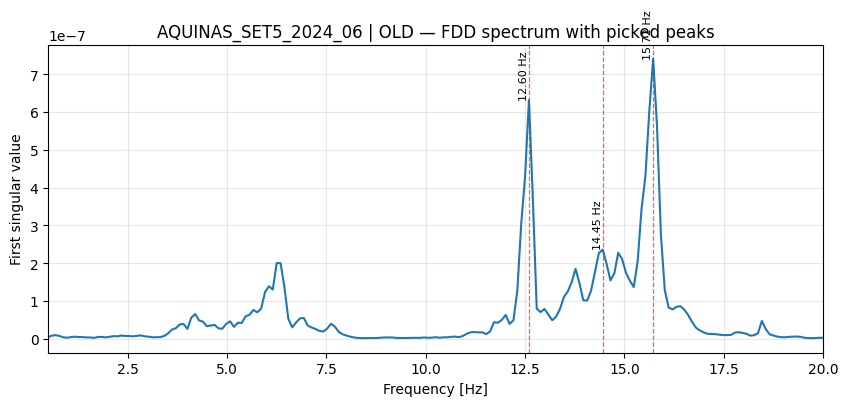

### AQUINAS_SET5_2024_06 | NEW

Frequency [Hz],Singular value
12.60,1.8489e-07
14.55,7.7296e-08
15.04,1.3009e-07


,Peak 1 (12.60 Hz),Peak 2 (14.55 Hz),Peak 3 (15.04 Hz)
Location,,,
S1_DO_INT,+0.085,+1.000,+1.000
S1_DO_MID,-0.085,+0.285,+0.175
S1_UP_INT,-0.002,-0.640,-0.218
S1_UP_MID,-0.054,-0.239,+0.028
S2_DO_INT,+1.000,+0.116,+0.035
S2_DO_MID,-0.345,-0.064,+0.090
S2_UP_INT,-0.052,+0.260,-0.037
S2_UP_MID,+0.035,+0.001,-0.001


,Peak 1 (12.60 Hz),Peak 2 (14.55 Hz),Peak 3 (15.04 Hz)
Location,,,
S1_DO_INT,0.086,1.000,1.000
S1_DO_MID,0.162,0.286,0.213
S1_UP_INT,0.012,0.930,0.941
S1_UP_MID,0.072,0.254,0.186
S2_DO_INT,1.000,0.122,0.057
S2_DO_MID,0.394,0.072,0.090
S2_UP_INT,0.052,0.269,0.038
S2_UP_MID,0.035,0.032,0.045


,Peak 1 (12.60 Hz),Peak 2 (14.55 Hz),Peak 3 (15.04 Hz)
Location,,,
S1_DO_INT,-10.7,-0.0,0.0
S1_DO_MID,-121.7,4.3,-34.5
S1_UP_INT,100.3,-133.5,103.4
S1_UP_MID,-138.4,-160.5,81.2
S2_DO_INT,0.0,-18.1,51.7
S2_DO_MID,-151.0,153.0,6.1
S2_UP_INT,-177.5,-15.3,-172.4
S2_UP_MID,-2.0,-88.8,91.6


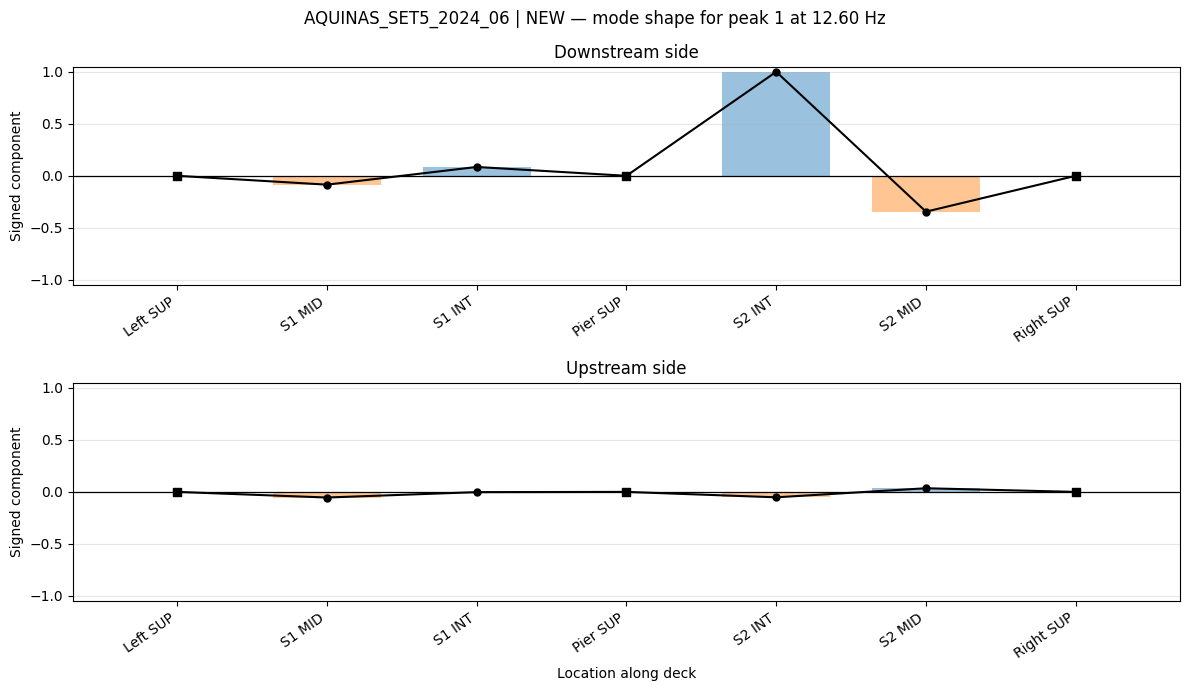

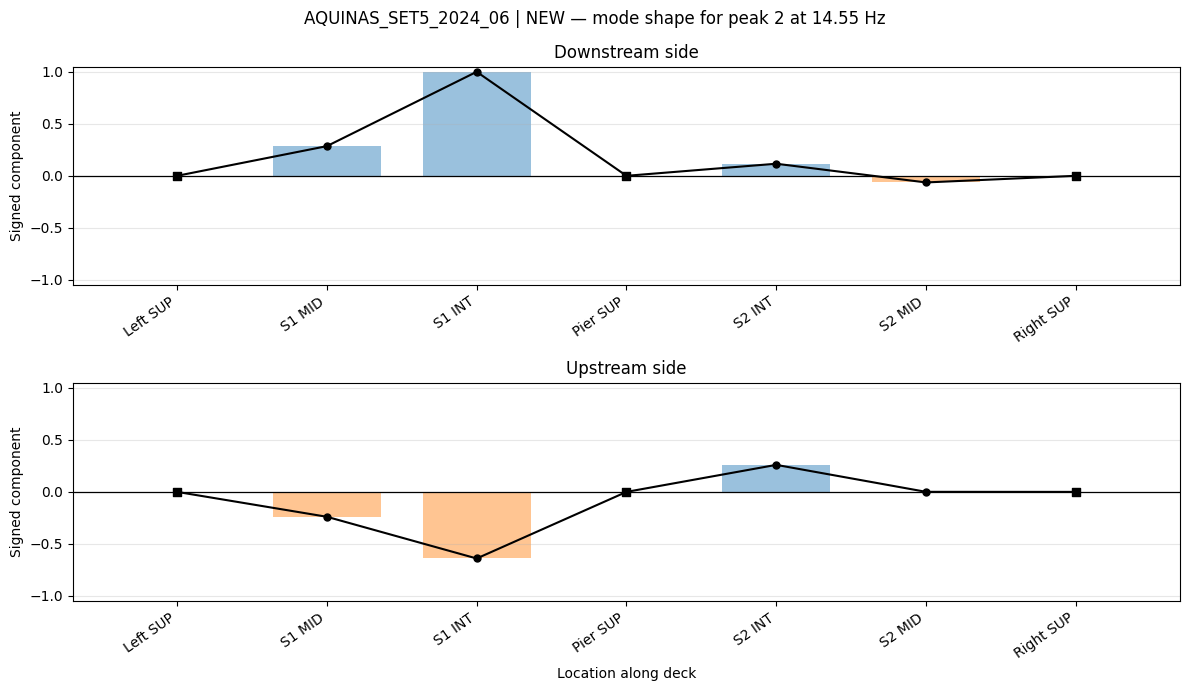

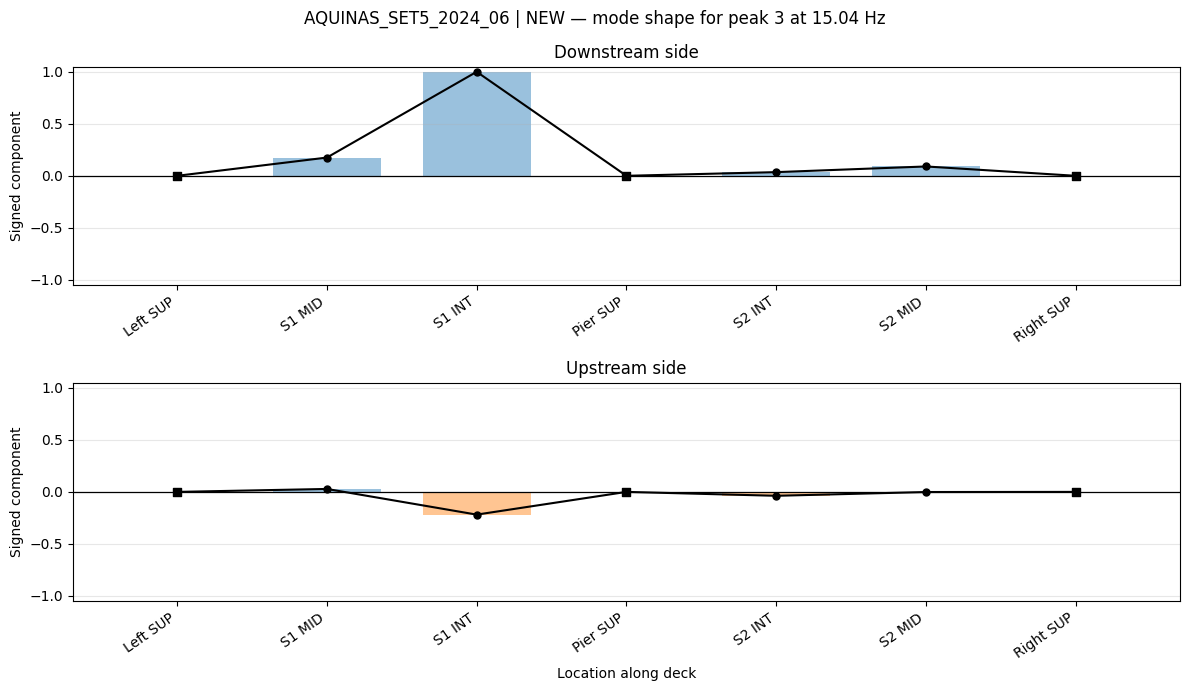

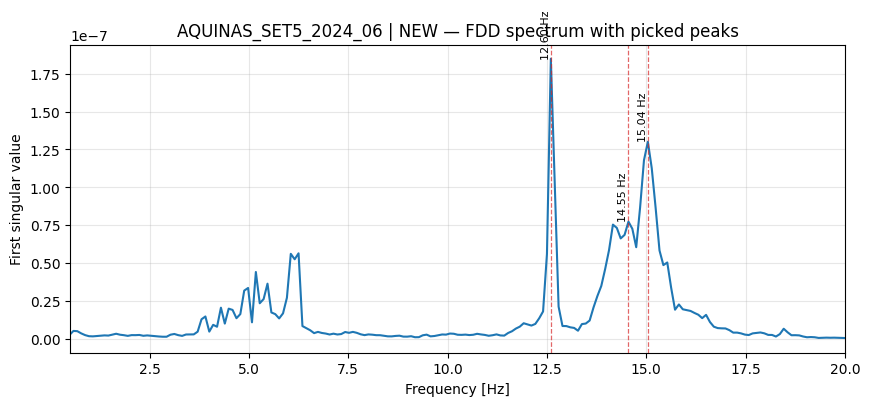

In [3]:
import matplotlib.pyplot as plt
import numpy as np

from aquinas_toolkit.feature_extraction import (
    annotate_mode_shape_locations,
    frequency_domain_decomposition,
    summarize_fdd_mode_shapes,
 )
from aquinas_toolkit.preprocessing import (
    bandpass_filter_waveform_matrix,
    find_common_sensor_events,
    load_common_event_waveform_matrix,
 )

SAMPLE_RATE_HZ = 100.0
LOW_HZ = 0.5
HIGH_HZ = 20.0
MAX_EVENTS_PER_SET = 5
TOP_MODE_COUNT = 3
DECKS = ["OLD", "NEW"]
SIDE_LABELS = {"DO": "Downstream side", "UP": "Upstream side"}
MODE_SHAPE_NODE_LAYOUT = [
    {"label": "Left SUP", "span": None, "location": "SUP", "value": 0.0},
    {"label": "S1 MID", "span": "S1", "location": "MID"},
    {"label": "S1 INT", "span": "S1", "location": "INT"},
    {"label": "Pier SUP", "span": None, "location": "SUP", "value": 0.0},
    {"label": "S2 INT", "span": "S2", "location": "INT"},
    {"label": "S2 MID", "span": "S2", "location": "MID"},
    {"label": "Right SUP", "span": None, "location": "SUP", "value": 0.0},
]

fdd_overview = []
fdd_results_by_set = {}

for set_dir in sorted(DATASET_ROOT.glob("AQUINAS_SET*")):
    reader = AquinasReader(set_dir)

    for deck in DECKS:
        common_events = find_common_sensor_events(
            reader,
            min_duration_seconds=MIN_DURATION_SECONDS,
            quantity="ACC",
            axis="Z",
            deck=deck,
        )
        if common_events.empty:
            continue

        selected_events = common_events if MAX_EVENTS_PER_SET is None else common_events.head(MAX_EVENTS_PER_SET)
        filtered_events = []
        channel_names = None

        for event in selected_events.itertuples(index=False):
            waveform_matrix = load_common_event_waveform_matrix(
                reader,
                start_time=event.Start_Time,
                end_time=event.End_Time,
                sensor_names=event.sensor_names,
            )
            if channel_names is None:
                channel_names = [column for column in waveform_matrix.columns if column != "timestamp"]
            filtered_matrix = bandpass_filter_waveform_matrix(
                waveform_matrix,
                sampling_rate_hz=SAMPLE_RATE_HZ,
                low_hz=LOW_HZ,
                high_hz=HIGH_HZ,
            )
            filtered_events.append(filtered_matrix)

        fdd_result = frequency_domain_decomposition(
            filtered_events,
            sampling_rate_hz=SAMPLE_RATE_HZ,
            nperseg=1024,
            noverlap=512,
        )
        peak_table, mode_shape_table = summarize_fdd_mode_shapes(
            fdd_result["frequencies_hz"],
            fdd_result["singular_values"],
            fdd_result["mode_shapes"],
            channel_names=channel_names,
            frequency_band_hz=(LOW_HZ, HIGH_HZ),
            n_peaks=TOP_MODE_COUNT,
        )
        mode_shape_locations = annotate_mode_shape_locations(mode_shape_table)

        amplitude_table = (
            mode_shape_locations.pivot(index="position_label", columns="peak_rank", values="mode_shape_amplitude")
            .rename_axis(index="Location", columns="Peak rank")
            .sort_index()
        )
        amplitude_table.columns = [
            f"Peak {peak_rank} ({float(peak_table.iloc[peak_rank - 1]['frequency_hz']):.2f} Hz)"
            for peak_rank in amplitude_table.columns
        ]

        signed_component_table = (
            mode_shape_locations.pivot(
                index="position_label",
                columns="peak_rank",
                values="mode_shape_signed_component",
            )
            .rename_axis(index="Location", columns="Peak rank")
            .sort_index()
        )
        signed_component_table.columns = [
            f"Peak {peak_rank} ({float(peak_table.iloc[peak_rank - 1]['frequency_hz']):.2f} Hz)"
            for peak_rank in signed_component_table.columns
        ]

        phase_table = (
            mode_shape_locations.pivot(index="position_label", columns="peak_rank", values="mode_shape_phase_deg")
            .rename_axis(index="Location", columns="Peak rank")
            .sort_index()
        )
        phase_table.columns = [
            f"Peak {peak_rank} ({float(peak_table.iloc[peak_rank - 1]['frequency_hz']):.2f} Hz)"
            for peak_rank in phase_table.columns
        ]

        result_key = f"{reader.set_name} | {deck}"
        fdd_overview.append(
            {
                "Dataset": reader.set_name,
                "Deck": deck,
                "ACC_Z channels": int(common_events["channel_count"].iloc[0]),
                "Aligned events available": len(common_events),
                "Aligned events used": len(selected_events),
                "Top FDD peak [Hz]": float(peak_table.iloc[0]["frequency_hz"]),
            }
        )
        fdd_results_by_set[result_key] = {
            "peak_table": peak_table,
            "mode_shape_locations": mode_shape_locations,
            "amplitude_table": amplitude_table,
            "signed_component_table": signed_component_table,
            "phase_table": phase_table,
            "frequencies_hz": fdd_result["frequencies_hz"],
            "first_singular_value": fdd_result["singular_values"][:, 0],
        }

display(
    pd.DataFrame(fdd_overview)
    .style.hide(axis="index")
    .format({
        "ACC_Z channels": "{:,.0f}",
        "Aligned events available": "{:,.0f}",
        "Aligned events used": "{:,.0f}",
        "Top FDD peak [Hz]": "{:.2f}",
    })
    .set_caption(
        f"Per-deck ACC_Z events after {MIN_DURATION_SECONDS:.0f} s duration filtering, 0.5-20 Hz zero-phase band-pass, and FDD"
    )
)

for result_key, result in fdd_results_by_set.items():
    display(Markdown(f"### {result_key}"))

    display(
        result["peak_table"][["frequency_hz", "singular_value"]]
        .rename(columns={"frequency_hz": "Frequency [Hz]", "singular_value": "Singular value"})
        .style.hide(axis="index")
        .format({"Frequency [Hz]": "{:.2f}", "Singular value": "{:.4e}"})
        .set_caption(f"{result_key} — picked FDD peaks")
    )

    display(
        result["signed_component_table"]
        .style
        .format("{:+.3f}")
        .set_caption(f"{result_key} — phase-aligned signed mode-shape components")
    )

    display(
        result["amplitude_table"]
        .style
        .format("{:.3f}")
        .set_caption(f"{result_key} — absolute mode-shape amplitudes")
    )

    display(
        result["phase_table"]
        .style
        .format("{:.1f}")
        .set_caption(f"{result_key} — location-based mode-shape phases [deg]")
    )

    for peak_rank, peak in enumerate(result["peak_table"].itertuples(index=False), start=1):
        peak_rows = result["mode_shape_locations"][result["mode_shape_locations"]["peak_rank"] == peak_rank].copy()
        peak_rows = peak_rows.sort_values(["side", "span", "location"])

        figure, axes = plt.subplots(2, 1, figsize=(12, 7), sharey=True)

        for axis, side in zip(axes, ["DO", "UP"], strict=True):
            side_rows = peak_rows[peak_rows["side"] == side].copy()
            plot_rows = []

            for node in MODE_SHAPE_NODE_LAYOUT:
                if node["span"] is None:
                    plot_rows.append(
                        {
                            "label": node["label"],
                            "signed_component": float(node["value"]),
                            "color": "tab:gray",
                            "is_support": True,
                        }
                    )
                    continue

                matching_rows = side_rows[
                    (side_rows["span"] == node["span"])
                    & (side_rows["location"] == node["location"])
                ]
                if matching_rows.empty:
                    plot_rows.append(
                        {
                            "label": node["label"],
                            "signed_component": np.nan,
                            "color": "tab:gray",
                            "is_support": False,
                        }
                    )
                    continue

                signed_component = float(matching_rows.iloc[0]["mode_shape_signed_component"])
                plot_rows.append(
                    {
                        "label": node["label"],
                        "signed_component": signed_component,
                        "color": "tab:blue" if signed_component >= 0 else "tab:orange",
                        "is_support": False,
                    }
                )

            plot_frame = pd.DataFrame(plot_rows)
            x_values = np.arange(len(plot_frame))

            axis.bar(
                x_values,
                plot_frame["signed_component"].fillna(0.0),
                color=plot_frame["color"],
                alpha=0.45,
                width=0.72,
            )
            axis.plot(
                x_values,
                plot_frame["signed_component"],
                color="black",
                linewidth=1.5,
                marker="o",
                markersize=5,
            )

            support_mask = plot_frame["is_support"].to_numpy()
            axis.scatter(
                x_values[support_mask],
                plot_frame.loc[support_mask, "signed_component"],
                color="black",
                marker="s",
                s=36,
                zorder=3,
            )

            axis.axhline(0.0, color="black", linewidth=0.9)
            axis.set_ylim(-1.05, 1.05)
            axis.set_ylabel("Signed component")
            axis.set_xticks(x_values, plot_frame["label"], rotation=35, ha="right")
            axis.set_title(SIDE_LABELS[side])
            axis.grid(axis="y", alpha=0.3)

        axes[-1].set_xlabel("Location along deck")
        figure.suptitle(
            f"{result_key} — mode shape for peak {peak_rank} at {peak.frequency_hz:.2f} Hz"
        )
        figure.tight_layout()
        plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(result["frequencies_hz"], result["first_singular_value"], linewidth=1.5)
    for peak in result["peak_table"].itertuples(index=False):
        plt.axvline(peak.frequency_hz, color="tab:red", linestyle="--", linewidth=0.9, alpha=0.7)
        plt.text(
            peak.frequency_hz,
            peak.singular_value,
            f"{peak.frequency_hz:.2f} Hz",
            rotation=90,
            va="bottom",
            ha="right",
            fontsize=8,
        )
    plt.xlim(LOW_HZ, HIGH_HZ)
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("First singular value")
    plt.title(f"{result_key} — FDD spectrum with picked peaks")
    plt.grid(alpha=0.3)
    plt.show()